In [3]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta, date
from textblob import TextBlob 
import time
import pytz
from pytrends.request import TrendReq
from pytrends.exceptions import TooManyRequestsError
from dateutil.relativedelta import relativedelta

# Configurable variables
asset = 'GLD'
company_name = 'Gold'
FETCH_GOOGLE_TRENDS = False  # Set to False to skip Google Trends pulling
custom_start_date = None
API_KEY = "8GPqXzjJbrN4AC5exf4RLw2d8E1uH2GD"
BACKOFF_INTERVAL = 60
MAX_RETRIES = 5
YEARS_BACK = 5  # Number of years back to pull historical data (adjusted for paid plan limit)

# Timeframes (restricted to relevant ones)
timeframes = [
    ('1h', 'hour', 1), ('4h', 'hour', 4),
    ('1d', 'day', 1), ('1w', 'week', 1)
]

eastern = pytz.timezone('America/New_York')

# Helper for retrying API requests
def get_with_retry(url, params):
    resp = requests.get(url, params=params)
    if resp.status_code == 429:
        time.sleep(BACKOFF_INTERVAL)
        resp = requests.get(url, params=params)
    resp.raise_for_status()
    return resp

# Generate 80-day chunks for Google Trends
def get_chunks(start_date, end_date):
    chunks = []
    current = start_date
    while current < end_date:
        next_chunk = min(current + timedelta(days=80), end_date)
        chunks.append((current, next_chunk))
        current = next_chunk + timedelta(days=1)
    return chunks

# Google Trends chunk pull with exponential backoff
def fetch_trends_in_chunks(keyword, start_date, end_date, geo='US', retries=MAX_RETRIES):
    pytrends = TrendReq(hl='en-US', tz=360)
    all_data = []
    chunks = get_chunks(start_date, end_date)

    for start, end in chunks:
        tf_str = f"{start.strftime('%Y-%m-%d')} {end.strftime('%Y-%m-%d')}"
        for attempt in range(retries):
            try:
                pytrends.build_payload([keyword], cat=0, timeframe=tf_str, geo=geo)
                df = pytrends.interest_over_time()
                if not df.empty:
                    df = df[[keyword]].reset_index()
                    df.rename(columns={keyword: 'search_volume'}, inplace=True)
                    df['date'] = df['date'].dt.date
                    all_data.append(df)
                    print(f"✅ Pulled Google Trends for chunk: {tf_str}", flush=True)
                    break
                else:
                    print(f"⚠️ Empty result for {tf_str}, retrying...", flush=True)
            except Exception as e:
                wait_time = 60 * (2 ** attempt)
                print(f"⏳ Retry {attempt+1} for {tf_str} due to error: {e} (waiting {wait_time}s)", flush=True)
                time.sleep(wait_time)
        else:
            print(f"❌ Failed to fetch Google Trends data for {tf_str} after {retries} retries.", flush=True)

    if all_data:
        print("✅ Google search volume has been successfully pulled and will be merged into CSVs.", flush=True)
        return pd.concat(all_data, ignore_index=True)
    else:
        return pd.DataFrame(columns=['date', 'search_volume'])

# Fetch corporate actions
def fetch_corporate_actions(ticker, start_date):
    actions = pd.DataFrame()
    types = ['splits', 'dividends']
    for action_type in types:
        endpoint = f"https://api.polygon.io/v3/reference/{action_type}"
        params = {"ticker": ticker, "apiKey": API_KEY, "limit": 1000}
        resp = get_with_retry(endpoint, params)
        data = resp.json().get('results', [])
        if data:
            df = pd.DataFrame(data)
            if action_type == 'splits':
                df['event_date'] = pd.to_datetime(df['execution_date']).dt.date
                df = df[['event_date', 'split_from', 'split_to']]
                df['split_ratio'] = df['split_to'] / df['split_from']
            elif action_type == 'dividends':
                df['event_date'] = pd.to_datetime(df['ex_dividend_date']).dt.date
                df = df[['event_date', 'cash_amount']]
            actions = pd.merge(actions, df, how='outer', on='event_date') if not actions.empty else df
    return actions.rename(columns={'event_date': 'date'})

# Fetch fundamentals data (financial reports) and prepare for merging
def fetch_fundamentals(ticker):
    endpoint = f"https://api.polygon.io/v3/reference/financials"
    params = {"ticker": ticker, "apiKey": API_KEY, "limit": 100}
    try:
        resp = get_with_retry(endpoint, params)
        data = resp.json().get('results', [])
        if data:
            df = pd.DataFrame(data)
            # Ensure there's a date column for merging; use 'as_of' if available
            if 'as_of' in df.columns:
                df['report_date'] = pd.to_datetime(df['as_of']).dt.date
            elif 'reportDate' in df.columns:
                df['report_date'] = pd.to_datetime(df['reportDate']).dt.date
            else:
                df['report_date'] = pd.NaT
            print(f"✅ Pulled fundamentals for {ticker}", flush=True)
            return df
    except Exception as e:
        print(f"⚠️ Failed to fetch fundamentals: {e}", flush=True)
    return pd.DataFrame()

# Modified fetch_timeframe to accept optional end_str and to merge fundamentals, plus feature engineering
def fetch_timeframe(ticker, label, span, multiplier, start_str, end_str=None, news_agg_df=None, search_trends_df=None, corp_actions_df=None, fundamentals_df=None):
    if end_str:
        print(f"Fetching {label} data from {start_str} to {end_str}...", flush=True)
        start_dt = pd.to_datetime(start_str)
        if start_dt.tzinfo is None:
            start_dt = eastern.localize(start_dt)
        start_ms = int(start_dt.astimezone(pytz.UTC).timestamp() * 1000)

        raw_end = pd.to_datetime(end_str)
        if raw_end.tzinfo is None:
            end_aware = eastern.localize(raw_end)
        else:
            end_aware = raw_end
        end_dt_utc = end_aware.astimezone(pytz.UTC)
        end_ts_utc = int(end_dt_utc.timestamp() * 1000)
    else:
        print(f"Fetching {label} data from {start_str} to now...", flush=True)
        start_dt = pd.to_datetime(start_str)
        if start_dt.tzinfo is None:
            start_dt = eastern.localize(start_dt)
        start_ms = int(start_dt.astimezone(pytz.UTC).timestamp() * 1000)
        if label == '1w':
            temp_end = datetime.now(eastern) - timedelta(days=datetime.now(eastern).weekday() + 1)
            temp_end = temp_end.replace(hour=0, minute=0, second=0, microsecond=0)
        else:
            temp_end = datetime.combine(datetime.now(eastern).date() - timedelta(days=1), datetime.max.time())
        if temp_end.tzinfo is None:
            temp_end = eastern.localize(temp_end)
        end_ts_utc = int(temp_end.astimezone(pytz.UTC).timestamp() * 1000)
        end_dt_utc = temp_end.astimezone(pytz.UTC)

    print(f"End timestamp cutoff for {label}: {end_dt_utc} UTC ms {end_ts_utc}", flush=True)

    all_rows = []
    limit = 50000

    while start_ms < end_ts_utc:
        url = f"https://api.polygon.io/v2/aggs/ticker/{ticker}/range/{multiplier}/{span}/{start_ms}/{end_ts_utc}"
        params = {"adjusted": "true", "sort": "asc", "limit": limit, "apiKey": API_KEY}
        try:
            resp = get_with_retry(url, params)
        except requests.exceptions.HTTPError as e:
            status = None
            if e.response is not None:
                status = e.response.status_code
            print(f"  ⚠️ Received HTTP {status} for {label} chunk {start_str} to {end_str or 'now'}. Skipping this chunk.", flush=True)
            break
        rows = resp.json().get('results', [])
        if not rows:
            print(f"  No rows returned for {label} between {start_str} and {end_str or 'now'}.", flush=True)
            break
        all_rows.extend(rows)
        last_ts = rows[-1]['t']
        print(f"  Pulled {len(rows)} rows; last_ts = {last_ts}", flush=True)

        if last_ts >= end_ts_utc:
            print("  ✅ Reached chunk end.", flush=True)
            break

        next_start_ms = last_ts + 1
        if next_start_ms <= start_ms:
            print("  ⚠️ No progress—exiting to prevent infinite loop.", flush=True)
            break
        start_ms = next_start_ms
        time.sleep(0.2)

    if not all_rows:
        return None

    df = pd.DataFrame(all_rows)
    df['timestamp'] = pd.to_datetime(df['t'], unit='ms', utc=True).dt.tz_convert(eastern)
    suffix = f"_{label}"
    df = df.rename(columns={
        'o': 'open'+suffix, 'h': 'high'+suffix, 'l': 'low'+suffix, 'c': 'close'+suffix,
        'v': 'volume'+suffix, 'n': 'transactions'+suffix
    })

    close_col = 'close' + suffix
    high_col = 'high' + suffix
    low_col = 'low' + suffix
    volume_col = 'volume' + suffix

    # Technical indicators already computed: SMA, RSI, MACD, Bollinger, ATR, OBV
    df['sma20'+suffix] = df[close_col].rolling(20).mean()
    df['sma50'+suffix] = df[close_col].rolling(50).mean()
    df['sma100'+suffix] = df[close_col].rolling(100).mean()
    df['sma200'+suffix] = df[close_col].rolling(200).mean()
    # ───> NEW: price vs. SMA booleans (1 if close > SMA, else 0)
    df['close_over_sma20'+suffix] = (df[close_col] > df['sma20'+suffix]).astype(int)
    df['close_over_sma50'+suffix] = (df[close_col] > df['sma50'+suffix]).astype(int)
    df['close_over_sma100'+suffix] = (df[close_col] > df['sma100'+suffix]).astype(int)
    df['close_over_sma200'+suffix] = (df[close_col] > df['sma200'+suffix]).astype(int)
    delta = df[close_col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    rs = gain.rolling(14).mean() / loss.rolling(14).mean()
    df['rsi14'+suffix] = 100 - (100 / (1 + rs))
    ema12 = df[close_col].ewm(span=12, adjust=False).mean()
    ema26 = df[close_col].ewm(span=26, adjust=False).mean()
    df['macd'+suffix] = ema12 - ema26
    df['macd_signal'+suffix] = df['macd'+suffix].ewm(span=9, adjust=False).mean()
    df['macd_hist'+suffix] = df['macd'+suffix] - df['macd_signal'+suffix]
    bb_mid = df['sma20'+suffix]
    bb_std = df[close_col].rolling(20).std()
    df['bb_upper'+suffix] = bb_mid + 2 * bb_std
    df['bb_lower'+suffix] = bb_mid - 2 * bb_std
    df['prev_close'+suffix] = df[close_col].shift(1)
    tr1 = df[high_col] - df[low_col]
    tr2 = (df[high_col] - df['prev_close'+suffix]).abs()
    tr3 = (df[low_col] - df['prev_close'+suffix]).abs()
    df['tr'+suffix] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    df['atr14'+suffix] = df['tr'+suffix].rolling(14).mean()
    df['obv'+suffix] = (np.sign(df[close_col].diff()) * df[volume_col]).fillna(0).cumsum()

    # Merge external datasets
    df['date'] = df['timestamp'].dt.date
    if news_agg_df is not None and not news_agg_df.empty:
        df = df.merge(news_agg_df, on='date', how='left')
        df[['news_count','avg_sentiment']] = df[['news_count','avg_sentiment']].fillna(0)
    if search_trends_df is not None and not search_trends_df.empty:
        df = df.merge(search_trends_df, on='date', how='left')
        df['search_volume'] = df['search_volume'].fillna(0)
    if corp_actions_df is not None and not corp_actions_df.empty:
        df = df.merge(corp_actions_df, on='date', how='left')

    # Merge fundamentals into timeframe data
    if fundamentals_df is not None and not fundamentals_df.empty:
        fund_df = fundamentals_df.copy()
        if 'report_date' in fund_df.columns:
            fund_merge = fund_df.drop(columns=[col for col in fund_df.columns if col not in ['report_date'] + [c for c in fund_df.columns if c != 'report_date']])
            df = df.merge(fund_merge, left_on='date', right_on='report_date', how='left')
            df.drop(columns=['report_date'], inplace=True)

    df.drop(columns=['date'], inplace=True)
    df = df.sort_values('timestamp').drop_duplicates(subset='timestamp', keep='first')

    # === FEATURE ENGINEERING ===
    # Compute log return
    df['log_return'+suffix] = np.log(df[close_col] / df[close_col].shift(1))
    # 5-period return
    df['ret_5'+suffix] = df[close_col].pct_change(5)
    # 5-period volatility (std of log returns)
    df['vol_5'+suffix] = df['log_return'+suffix].rolling(window=5).std()
    # 20-period average volume and volume ratio
    df['avg_vol_20'+suffix] = df[volume_col].rolling(window=20).mean()
    df['vol_ratio'+suffix] = df[volume_col] / df['avg_vol_20'+suffix]
    # VWAP (cumulative price*volume / cumulative volume)
    df['cum_vol_price'+suffix] = (df[close_col] * df[volume_col]).cumsum()
    df['cum_vol'+suffix] = df[volume_col].cumsum()
    df['vwap'+suffix] = df['cum_vol_price'+suffix] / df['cum_vol'+suffix]
    # Stochastic Oscillator (14-period)
    low_14 = df[low_col].rolling(window=14).min()
    high_14 = df[high_col].rolling(window=14).max()
    df['stoch_k'+suffix] = 100 * (df[close_col] - low_14) / (high_14 - low_14)
    df['stoch_d'+suffix] = df['stoch_k'+suffix].rolling(window=3).mean()
    # Calendar features
    df['dow'+suffix] = df['timestamp'].dt.weekday
    df['month'+suffix] = df['timestamp'].dt.month
    # Sentiment lags and rolling means if available
    if 'avg_sentiment' in df.columns:
        df['avg_sentiment_lag1'+suffix] = df['avg_sentiment'].shift(1)
        df['sentiment_5d_ma'+suffix] = df['avg_sentiment'].rolling(window=5).mean()
    # Search volume rolling mean if available
    if 'search_volume' in df.columns:
        df['search_vol_5d_ma'+suffix] = df['search_volume'].rolling(window=5).mean()

    # === END FEATURE ENGINEERING ===

    # Save CSV
    df.to_csv(f"data_{label}.csv", index=False)
    print(f"✅ Saved data_{label}.csv with {len(df)} rows", flush=True)
    return df

# === Main Execution ===
now = datetime.now(eastern)
earliest_start_date = (now - relativedelta(years=YEARS_BACK)).date()
price_data_start_date = pd.to_datetime(custom_start_date).date() if custom_start_date else earliest_start_date
trends_data_start_date = datetime.now().date() - timedelta(days=80)
overall_end_date = datetime.now().date() - timedelta(days=1)
start = price_data_start_date.isoformat()
print(f"Starting data fetch for {asset} from {start} to now (Eastern Time)\n", flush=True)

# Fetch news data
print("Fetching news...", flush=True)
resp = get_with_retry("https://api.polygon.io/v2/reference/news", {"ticker": asset, "limit": 500, "apiKey": API_KEY})
news_df = pd.DataFrame(resp.json().get('results', []))
agg_news_df = pd.DataFrame()
if not news_df.empty:
    news_df['published_utc'] = pd.to_datetime(news_df['published_utc'], utc=True).dt.tz_convert(eastern)
    news_df['date'] = news_df['published_utc'].dt.date
    news_df['sentiment'] = news_df['title'].apply(lambda t: TextBlob(t).sentiment.polarity)
    agg_news_df = news_df.groupby('date').agg(news_count=('sentiment','count'), avg_sentiment=('sentiment','mean')).reset_index()

# Fetch Google Trends data (past 80 days)
search_trends_df = pd.DataFrame()
if FETCH_GOOGLE_TRENDS:
    print("Fetching Google Trends search volume...\n", flush=True)
    search_trends_df = fetch_trends_in_chunks(company_name, trends_data_start_date, overall_end_date)

# Fetch corporate actions (splits, dividends)
corp_actions_df = fetch_corporate_actions(asset, price_data_start_date)

# Fetch fundamentals data and prepare for merging
fundamentals_df = fetch_fundamentals(asset)

# Calculate end timestamp (15 minutes delayed from now)
end_datetime = datetime.now(eastern) - timedelta(minutes=15)
end_str = end_datetime.isoformat()

# Loop through each timeframe to fetch past 5 years up to 15 minutes ago
for label, span, mult in timeframes:
    start_str = price_data_start_date.isoformat()
    df = fetch_timeframe(asset, label, span, mult, start_str, end_str,
                         news_agg_df=agg_news_df,
                         search_trends_df=search_trends_df,
                         corp_actions_df=corp_actions_df,
                         fundamentals_df=fundamentals_df)
    # Skip and continue if nothing returned
    if df is None:
        print(f"⚠️ No data for {label}. Continuing to next timeframe.", flush=True)
        continue

    # CSV saving is handled within fetch_timeframe

print("✅ Data fetch complete for all timeframes.")

# === FEATURE AUGMENTATION (Append new features to each data_<label>.csv) ===

# List of timeframe labels matching your CSV filenames: data_<label>.csv
labels = ['1h', '4h', '1d', '1w']

for label in labels:
    suffix = f'_{label}'                    # e.g. "_5m"
    fname = f"data_{label}.csv"             # e.g. "data_5m.csv"

    # ─── LOAD WITHOUT parse_dates ───
    df = pd.read_csv(fname)

    # Convert TZ-aware string → UTC → Eastern → naive
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True) \
                       .dt.tz_convert(eastern) \
                       .dt.tz_localize(None)
    
    # ─── NEW: add 1-bar and 2-bar lagged closes ───
    close_col = 'close' + suffix
    df['close_lag1' + suffix] = df[close_col].shift(1)
    df['close_lag2' + suffix] = df[close_col].shift(2)
    df['close_lag3' + suffix] = df[close_col].shift(3)
    df['close_lag4' + suffix] = df[close_col].shift(4)
    df['close_lag5' + suffix] = df[close_col].shift(5)
    # (You can drop or fill NaNs later if desired; training script will drop rows with NaNs.)

    # Define column-names used repeatedly
    close_col    = 'close'   + suffix
    high_col     = 'high'    + suffix
    low_col      = 'low'     + suffix
    volume_col   = 'volume'  + suffix
    atr_col      = 'atr14'   + suffix   # ATR(14) column already exists
    logret_col   = 'log_return' + suffix
    ret5_col     = 'ret_5'   + suffix
    vol5_col     = 'vol_5'   + suffix
    avgvol20_col = 'avg_vol_20' + suffix

    # ─── 1) EMA(12) & EMA(26) and EMA Crossover flag ───
    df['ema12'    + suffix] = df[close_col].ewm(span=12, adjust=False).mean()
    df['ema26'    + suffix] = df[close_col].ewm(span=26, adjust=False).mean()
    df['ema_diff' + suffix] = df['ema12'+suffix] - df['ema26'+suffix]
    df['ema_cross'+ suffix] = (df['ema_diff'+suffix] > 0).astype(int)

    # ─── 2) ATR-based Bands (using existing ATR(14)) ───
    df['upper_atr_band'+suffix] = df[close_col] + 2 * df[atr_col]
    df['lower_atr_band'+suffix] = df[close_col] - 2 * df[atr_col]

    # ─── 3) Chaikin Money Flow (CMF(20)) ───
    tp = (df[high_col] + df[low_col] + df[close_col]) / 3
    high_low_diff = df[high_col] - df[low_col]
    # Avoid division by zero
    money_flow_mult = np.where(
        high_low_diff != 0,
        ((df[close_col] - df[low_col]) - (df[high_col] - df[close_col])) / high_low_diff,
        0
    )
    money_flow_vol = money_flow_mult * df[volume_col]
    df['cmf20'+suffix] = (
        money_flow_vol.rolling(window=20, min_periods=1).sum()
        / (df[volume_col].rolling(window=20, min_periods=1).sum() + 1e-8)
    )

    # ─── 4) ADX(14) and Directional Indicators (DI⁺14, DI⁻14, DX, ADX14) ───
    df['prev_high' + suffix] = df[high_col].shift(1)
    df['prev_low'  + suffix] = df[low_col].shift(1)

    up_move   = df[high_col] - df['prev_high'+suffix]
    down_move = df['prev_low' +suffix] - df[low_col]

    df['plus_dm'  +suffix] = np.where(
        (up_move > down_move) & (up_move > 0),
        up_move, 0
    )
    df['minus_dm' +suffix] = np.where(
        (down_move > up_move) & (down_move > 0),
        down_move, 0
    )

    # True Range (TR) already computed as 'tr'+suffix in your pipeline
    tr14_sum       = df['tr' + suffix].rolling(window=14, min_periods=1).sum()
    plus_dm14_sum  = df['plus_dm' +suffix].rolling(window=14, min_periods=1).sum()
    minus_dm14_sum = df['minus_dm'+suffix].rolling(window=14, min_periods=1).sum()

    df['plus_di14' +suffix] = 100 * plus_dm14_sum   / (tr14_sum + 1e-8)
    df['minus_di14'+suffix] = 100 * minus_dm14_sum  / (tr14_sum + 1e-8)
    df['dx'       +suffix] = 100 * np.abs(
        df['plus_di14'+suffix] - df['minus_di14'+suffix]
    ) / (df['plus_di14'+suffix] + df['minus_di14'+suffix] + 1e-8)
    df['adx14'    +suffix] = df['dx'+suffix].rolling(window=14, min_periods=1).mean()

    # ─── 5) Commodity Channel Index (CCI(20)) ───
    tp = (df[high_col] + df[low_col] + df[close_col]) / 3
    tp_ma20 = tp.rolling(window=20, min_periods=1).mean()
    tp_md20 = tp.rolling(window=20, min_periods=1).apply(
        lambda x: np.mean(np.abs(x - np.mean(x))), raw=True
    )
    df['cci20'+suffix] = (tp - tp_ma20) / (0.015 * (tp_md20 + 1e-8))

    # ─── 6) Volume Price Trend (VPT) ───
    df['vpt'+suffix] = (df[volume_col] * df[close_col].pct_change()).cumsum().fillna(0)

    # ─── 7) Rolling Skewness and Kurtosis of log returns (10-bar) ───
    df['roll_skew_10'+suffix] = df[logret_col].rolling(window=10, min_periods=1).skew()
    df['roll_kurt_10'+suffix] = df[logret_col].rolling(window=10, min_periods=1).kurt()

    # ─── 8) Multi-horizon returns ───
    df['ret_10'+suffix] = df[close_col].pct_change(10)
    df['ret_20'+suffix] = df[close_col].pct_change(20)
    df['ret_50'+suffix] = df[close_col].pct_change(50)

    # ─── 9) Momentum-to-Volatility Ratio: ret_5 / vol_5 ───
    df['mom_vol_ratio'+suffix] = df[ret5_col] / (df[vol5_col] + 1e-8)

    # ─── 10) Volume Spike Flag: volume > 2 × avg_volume_20 ───
    df['vol_spike'+suffix] = (df[volume_col] > 2 * df[avgvol20_col]).astype(int)

    # ─── 11) Calendar Features: Month-End, Quarter-End, Year-End ───
    if label in ['1d', '1w']:
        df['is_day_end' + suffix] = 1
        df['is_week_end' + suffix] = (df['timestamp'].dt.weekday == 4).astype(int)
    else:
        four_pm = datetime.strptime("16:00", "%H:%M").time()
        df['is_day_end' + suffix] = (df['timestamp'].dt.time == four_pm).astype(int)
        df['is_week_end' + suffix] = (
            (df['timestamp'].dt.weekday == 4) &
            (df['timestamp'].dt.time == four_pm)
        ).astype(int)
    
    df['is_month_end'   + suffix] = df['timestamp'].dt.is_month_end.astype(int)
    df['is_quarter_end' + suffix] = df['timestamp'].dt.is_quarter_end.astype(int)
    df['is_year_end'    + suffix] = df['timestamp'].dt.is_year_end.astype(int)


    # ─── Clean up intermediate helper columns ───
    df.drop(columns=[
        'prev_high'+suffix, 'prev_low'+suffix,
        'plus_dm'  +suffix, 'minus_dm'+suffix,
        'dx'       +suffix
    ], inplace=True, errors='ignore')

    # ─── Save the updated CSV back out ───
    df.to_csv(fname, index=False)
    print(f"✅ Updated {fname} with new features (total columns: {len(df.columns)})")


Starting data fetch for GLD from 2020-06-17 to now (Eastern Time)
ERROR! Session/line number was not unique in database. History logging moved to new session 154

Fetching news...
⚠️ Failed to fetch fundamentals: 404 Client Error: Not Found for url: https://api.polygon.io/v3/reference/financials?ticker=GLD&apiKey=8GPqXzjJbrN4AC5exf4RLw2d8E1uH2GD&limit=100
Fetching 1h data from 2020-06-17 to 2025-06-17T07:02:52.296620-04:00...
End timestamp cutoff for 1h: 2025-06-17 11:02:52.296620+00:00 UTC ms 1750158172296
  Pulled 1320 rows; last_ts = 1602698400000
  Pulled 1402 rows; last_ts = 1614096000000
  Pulled 1453 rows; last_ts = 1625608800000
  Pulled 1523 rows; last_ts = 1637586000000
  Pulled 1440 rows; last_ts = 1649160000000
  Pulled 1529 rows; last_ts = 1661526000000
  Pulled 1570 rows; last_ts = 1674583200000
  Pulled 1534 rows; last_ts = 1686769200000
  Pulled 1558 rows; last_ts = 1699635600000
  Pulled 1547 rows; last_ts = 1712678400000
  Pulled 1517 rows; last_ts = 1724680800000
  P


--- 1H MODEL (returns target, all features) ---
Using 71 features
Fold 1/5: train 0→3264, test 3264→6528
Fold 2/5: train 0→6528, test 6528→9792
Fold 3/5: train 0→9792, test 9792→13056
Fold 4/5: train 0→13056, test 13056→16320
Fold 5/5: train 0→16320, test 16320→19589
[1h] MAE: 0.4278, RMSE: 0.6414
  Price accuracy: 99.79%   Direction accuracy: 50.81%
Next-bar direction accuracy: 47.51% over 16324 bars


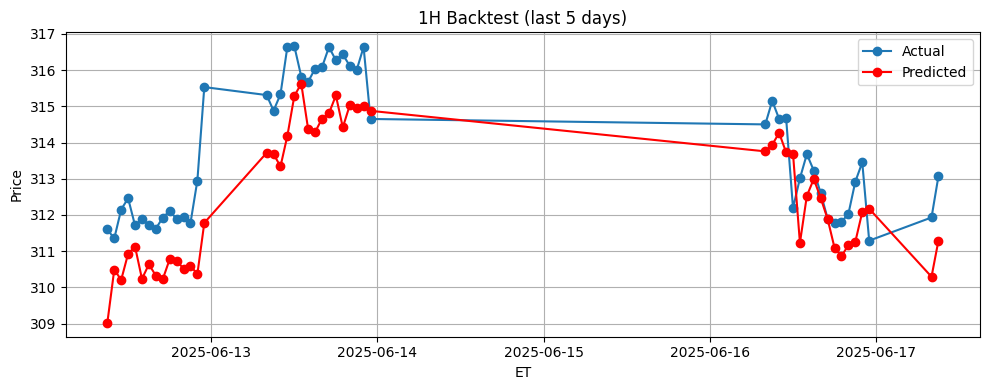

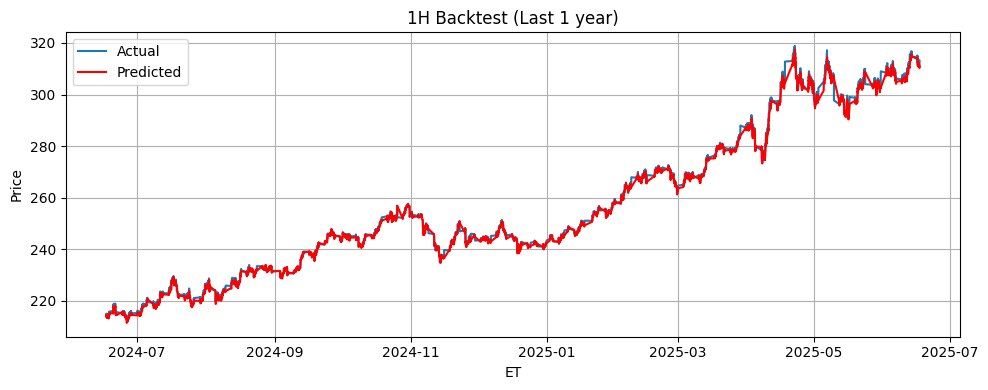

Equity backtest window: 2020-06-17 → 2025-06-17
Equity final (5-year): $112.13 (12.13% return)
Total trades (5-year): 912
Max drawdown (5-year): 16.94%
Win rate (5-year): 54.93%


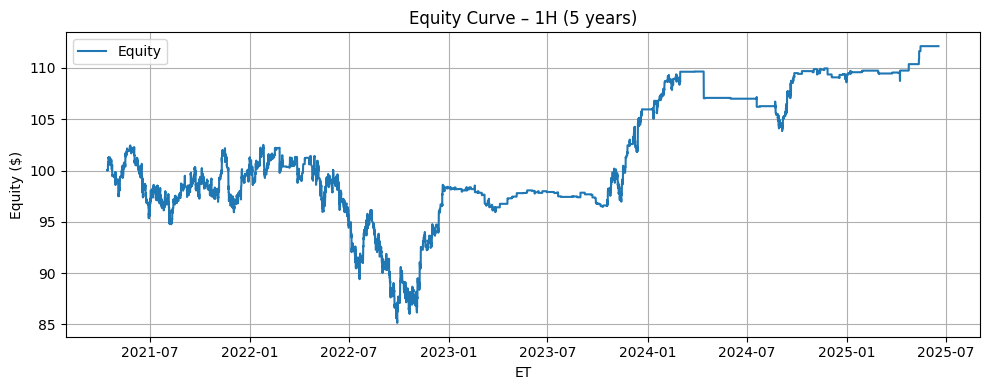

Retraining on full history for next-bar forecast…
Next-bar (1h) at 2025-06-17 08:00 ET → $312.67, dir=0


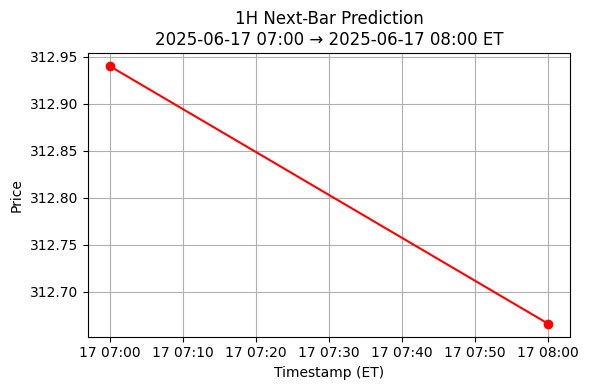


--- 4H MODEL (returns target, all features) ---
Using 71 features
Fold 1/5: train 0→904, test 904→1808
Fold 2/5: train 0→1808, test 1808→2712
Fold 3/5: train 0→2712, test 2712→3616
Fold 4/5: train 0→3616, test 3616→4520
Fold 5/5: train 0→4520, test 4520→5425
[4h] MAE: 0.7147, RMSE: 1.0654
  Price accuracy: 99.64%   Direction accuracy: 51.27%
Next-bar direction accuracy: 49.76% over 4520 bars


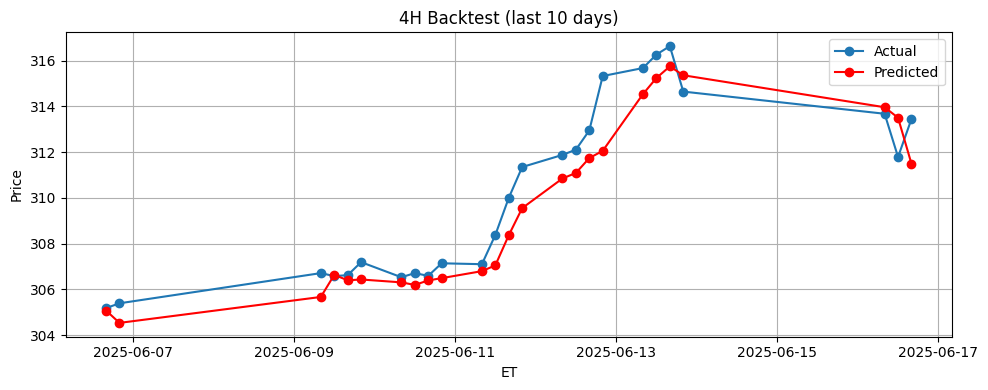

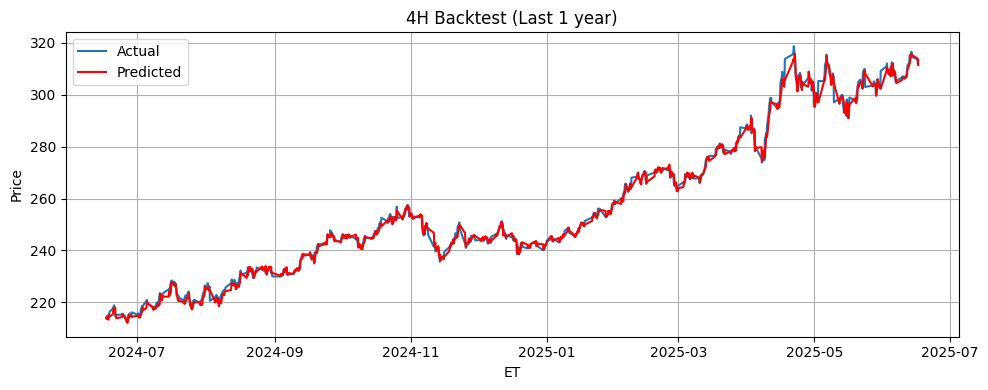

Equity backtest window: 2020-06-16 → 2025-06-16
Equity final (5-year): $139.65 (39.65% return)
Total trades (5-year): 447
Max drawdown (5-year): 10.67%
Win rate (5-year): 57.27%


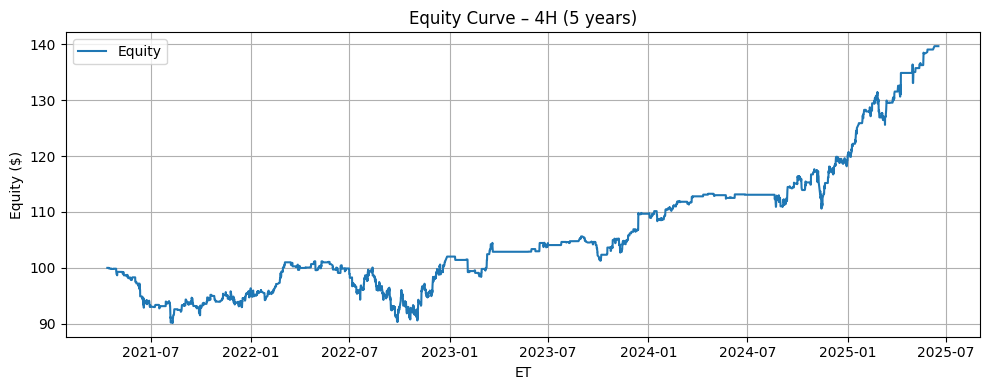

Retraining on full history for next-bar forecast…
Next-bar (4h) at 2025-06-17 08:00 ET → $312.42, dir=0


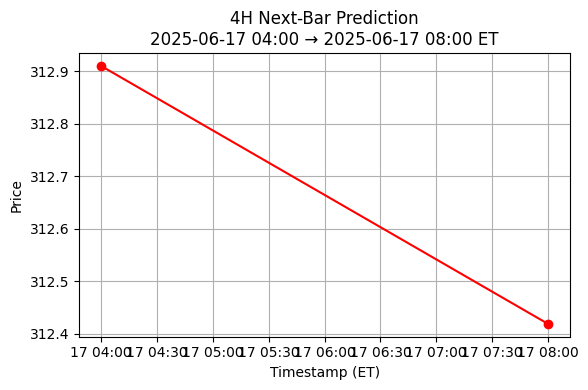


--- 1D MODEL (returns target, all features) ---
Using 71 features
Fold 1/5: train 0→209, test 209→418
Fold 2/5: train 0→418, test 418→627
Fold 3/5: train 0→627, test 627→836
Fold 4/5: train 0→836, test 836→1045
Fold 5/5: train 0→1045, test 1045→1254
[1d] MAE: 2.1242, RMSE: 2.8075
  Price accuracy: 98.96%   Direction accuracy: 51.39%
Next-bar direction accuracy: 48.95% over 1044 bars


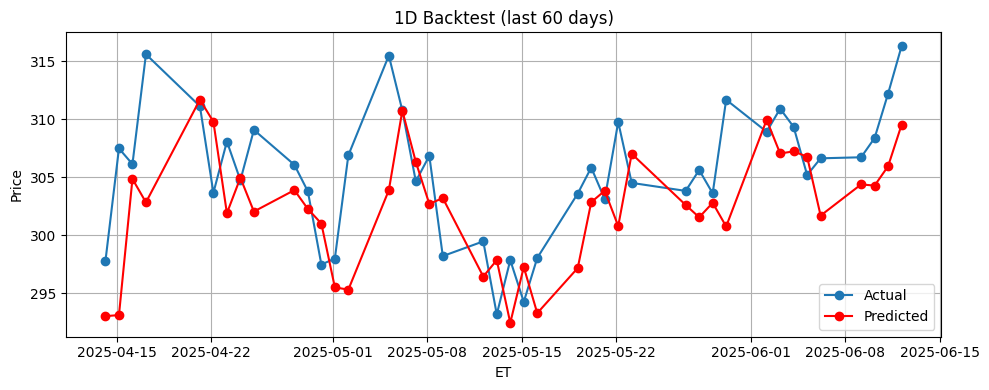

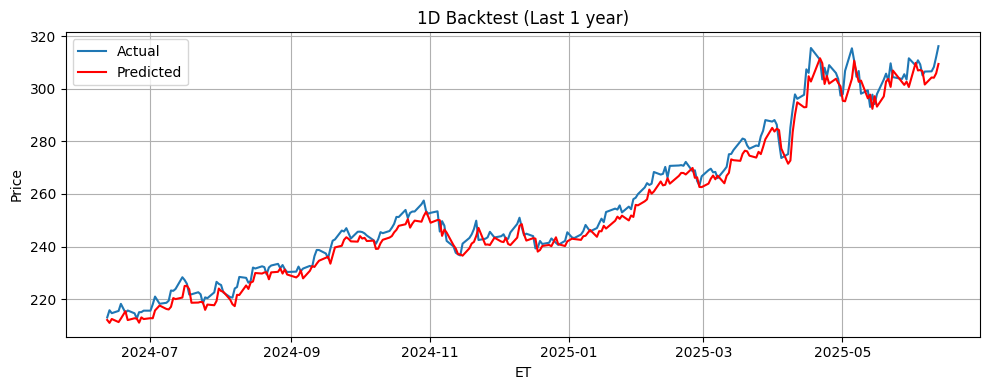

Equity backtest window: 2020-06-12 → 2025-06-12
Equity final (5-year): $129.09 (29.09% return)
Total trades (5-year): 68
Max drawdown (5-year): 10.23%
Win rate (5-year): 69.12%


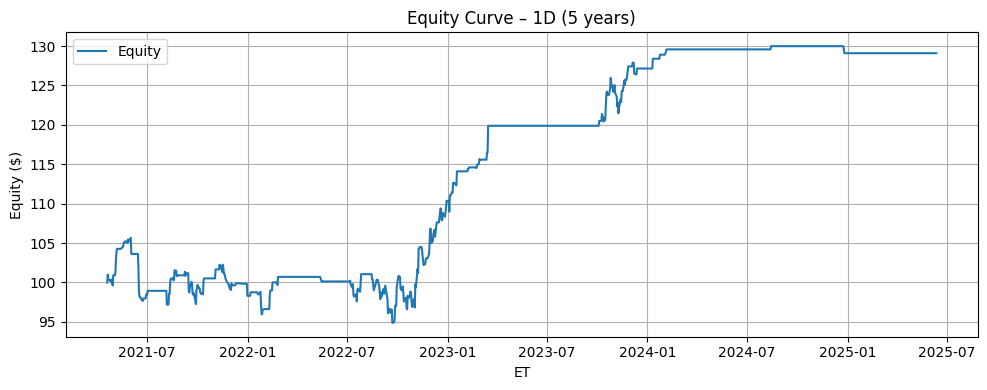

Retraining on full history for next-bar forecast…
Next-bar (1d) at 2025-06-17 00:00 ET → $311.73, dir=0


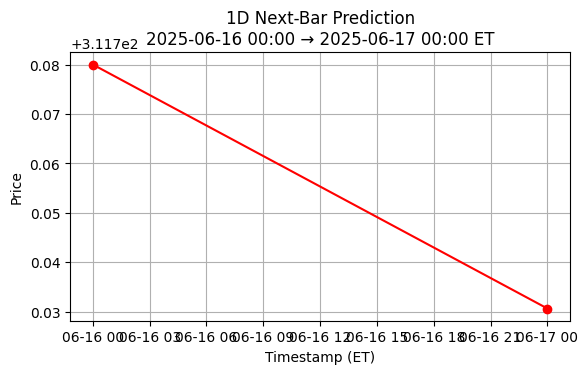


--- 1W MODEL (returns target, all features) ---
Using 71 features
Fold 1/5: train 0→43, test 43→86
Fold 2/5: train 0→86, test 86→129
Fold 3/5: train 0→129, test 129→172
Fold 4/5: train 0→172, test 172→215
Fold 5/5: train 0→215, test 215→261
[1w] MAE: 3.9632, RMSE: 5.1991
  Price accuracy: 98.04%   Direction accuracy: 54.13%
Next-bar direction accuracy: 52.53% over 217 bars


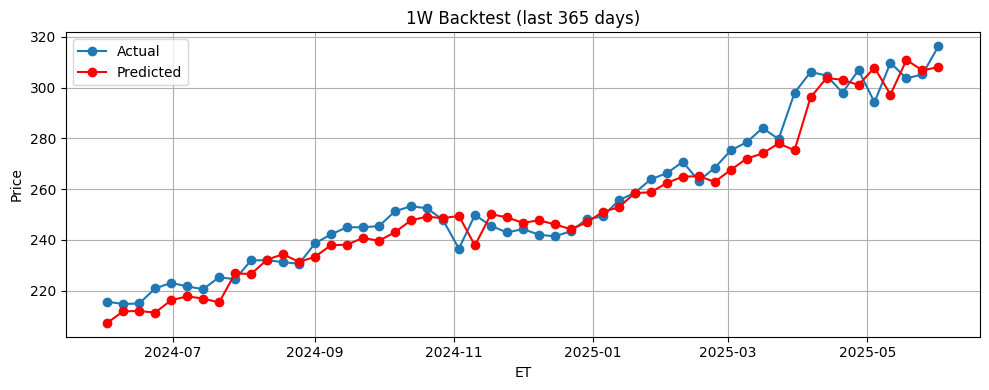

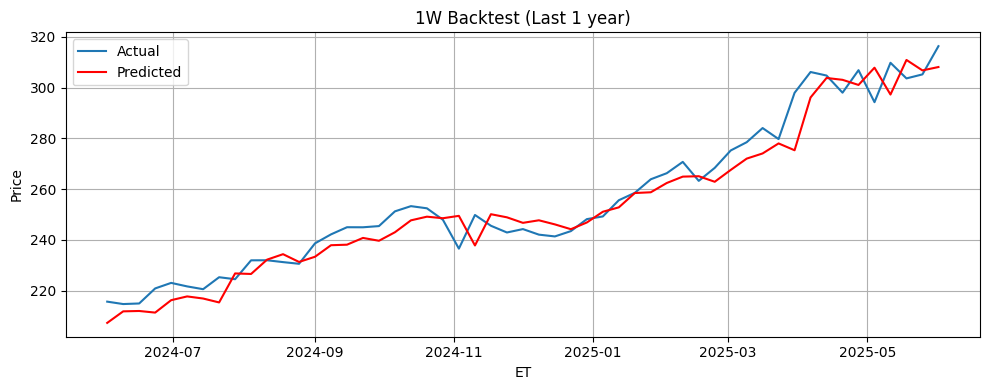

Equity backtest window: 2020-06-01 → 2025-06-01
Equity final (5-year): $136.95 (36.95% return)
Total trades (5-year): 19
Max drawdown (5-year): 9.19%
Win rate (5-year): 66.67%


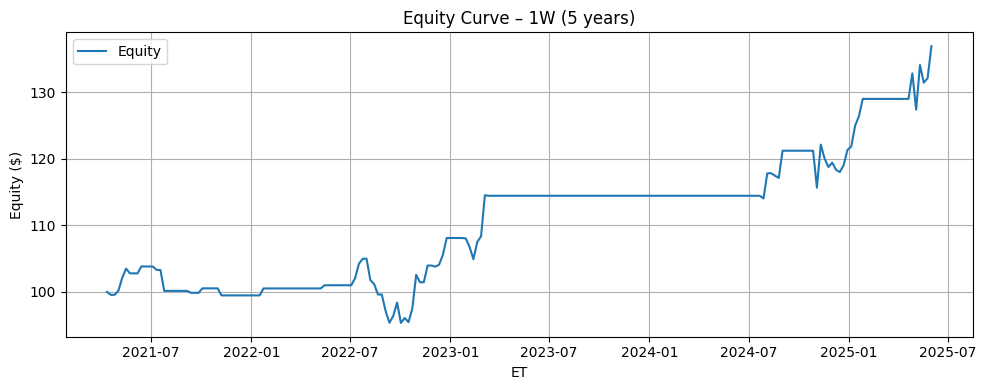

Retraining on full history for next-bar forecast…
Next-bar (1w) at 2025-06-22 00:00 ET → $314.02, dir=1


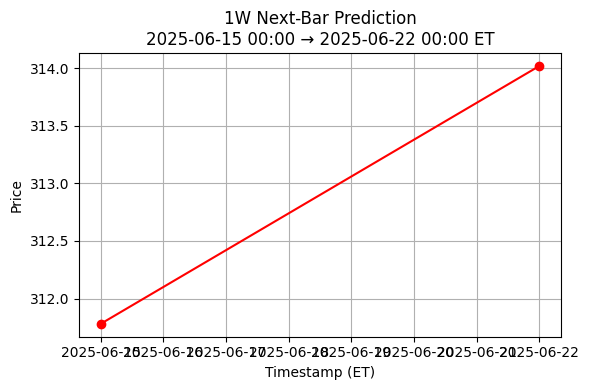

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score, mean_squared_error
import pytz

# --- Trading simulation function without stop-loss ---
def simulate_trading(df_eval, initial_capital=100.0, profit_target=1.00, stop_loss=1.00):
    capital = initial_capital
    shares = 0.0
    equity_curve = []
    n_trades = 0
    win_trades = 0
    closed_trades = 0
    peak_equity = initial_capital
    max_drawdown = 0.0
    entry_price = None

    for i in range(len(df_eval) - 1):
        price = df_eval.iloc[i]['actual']
        next_pred = df_eval.iloc[i+1]['predicted']

        if next_pred > price and shares == 0:
            shares = capital / price
            entry_price = price
            n_trades += 1
        # if we already hold shares, first check profit/stop thresholds
        elif shares > 0:
            ret_since_entry = (price / entry_price) - 1.0
            # take-profit
            if ret_since_entry >= profit_target:
                capital = shares * price
                shares = 0.0
                closed_trades += 1
                win_trades += 1
                entry_price = None
            # stop-loss
            elif ret_since_entry <= -stop_loss:
                capital = shares * price
                shares = 0.0
                closed_trades += 1
                entry_price = None
            # otherwise, exit on reversal as before
            elif next_pred < price:
                capital = shares * price
                shares = 0.0
                closed_trades += 1
                if price > entry_price:
                    win_trades += 1
                entry_price = None
        
        equity = shares * price if shares > 0 else capital
        equity_curve.append({'timestamp': df_eval.iloc[i]['timestamp'], 'equity': equity})

        peak_equity = max(peak_equity, equity)
        drawdown = (peak_equity - equity) / peak_equity
        max_drawdown = max(max_drawdown, drawdown)

    last_price = df_eval.iloc[-1]['actual']
    final_equity = shares * last_price if shares > 0 else capital
    equity_curve.append({'timestamp': df_eval.iloc[-1]['timestamp'], 'equity': final_equity})

    peak_equity = max(peak_equity, final_equity)
    drawdown = (peak_equity - final_equity) / peak_equity
    max_drawdown = max(max_drawdown, drawdown)

    win_rate = (win_trades / closed_trades) if closed_trades > 0 else 0.0
    return pd.DataFrame(equity_curve), n_trades, max_drawdown, win_rate

# --- Main function with walk-forward testing ---
def run_model(file_path, freq_label, plot_days, n_splits=5):
    print(f"\n--- {freq_label.upper()} MODEL (returns target, all features) ---")
    eastern = pytz.timezone('America/New_York')

    df = pd.read_csv(file_path, parse_dates=['timestamp'])
    df['timestamp'] = df['timestamp'].dt.tz_localize(eastern)
    df.sort_values('timestamp', inplace=True)

    df['target_price']  = df[f'close_{freq_label}'].shift(-1)
    df['target_return'] = df['target_price'] / df[f'close_{freq_label}'] - 1
    df['target_bin']    = (df['target_return'] > 0).astype(int)
    df.dropna(subset=['target_price','target_return','target_bin'], inplace=True)

    exclude = {'timestamp','target_price','target_return','target_bin'}
    features = [c for c in df.columns if c not in exclude]
    print(f"Using {len(features)} features")

    total_len = len(df)
    split_size = total_len // (n_splits + 1)
    all_preds_price, all_trues_price = [], []
    all_preds_bin, all_trues_bin = [], []
    all_times = []

    xgb_params_reg = dict(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, gamma=0.0,
        min_child_weight=1, reg_alpha=0.0, reg_lambda=1.0,
        tree_method='hist', random_state=42,
        objective='reg:squarederror', verbosity=0
    )
    xgb_params_clf = dict(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, gamma=0.0,
        min_child_weight=1, reg_alpha=0.0, reg_lambda=1.0,
        scale_pos_weight=1.0, tree_method='hist', random_state=42,
        objective='binary:logistic', eval_metric='logloss', verbosity=0
    )

    for fold in range(n_splits):
        train_end = split_size * (fold + 1)
        test_start = train_end
        test_end = split_size * (fold + 2) if fold < n_splits - 1 else total_len
        print(f"Fold {fold+1}/{n_splits}: train 0→{train_end}, test {test_start}→{test_end}")

        train_idx = list(range(train_end))
        test_idx = list(range(test_start, test_end))

        X_train = df.iloc[train_idx][features].values
        y_train_ret = df.iloc[train_idx]['target_return'].values
        y_train_bin = df.iloc[train_idx]['target_bin'].values

        X_test = df.iloc[test_idx][features].values
        closes_test = df.iloc[test_idx][f'close_{freq_label}'].values
        y_test_price = df.iloc[test_idx]['target_price'].values
        y_test_bin = df.iloc[test_idx]['target_bin'].values

        reg = XGBRegressor(**xgb_params_reg)
        reg.fit(X_train, y_train_ret)
        preds_price = closes_test * (1 + reg.predict(X_test))

        clf = XGBClassifier(**xgb_params_clf)
        clf.fit(X_train, y_train_bin)
        preds_bin = clf.predict(X_test)

        all_preds_price.extend(preds_price)
        all_trues_price.extend(y_test_price)
        all_preds_bin.extend(preds_bin)
        all_trues_bin.extend(y_test_bin)
        all_times.extend(df.iloc[test_idx]['timestamp'].values)

    mae = mean_absolute_error(all_trues_price, all_preds_price)
    rmse = np.sqrt(mean_squared_error(all_trues_price, all_preds_price))
    reg_acc = 100 - np.mean(np.abs((np.array(all_trues_price) - all_preds_price) / (np.array(all_trues_price) + 1e-8))) * 100
    bin_acc = accuracy_score(all_trues_bin, all_preds_bin) * 100
    print(f"[{freq_label}] MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    print(f"  Price accuracy: {reg_acc:.2f}%   Direction accuracy: {bin_acc:.2f}%")

    df_eval = pd.DataFrame({
        'timestamp': all_times,
        'actual': all_trues_price,
        'predicted': all_preds_price
    }).sort_values('timestamp').reset_index(drop=True)
    df_eval['act_dir'] = (df_eval['actual'].shift(-1) > df_eval['actual']).astype(int)
    df_eval['pred_dir'] = (df_eval['predicted'].shift(-1) > df_eval['predicted']).astype(int)
    df_eval = df_eval.iloc[:-1]
    dir_acc = (df_eval['act_dir'] == df_eval['pred_dir']).mean() * 100
    print(f"Next-bar direction accuracy: {dir_acc:.2f}% over {len(df_eval)} bars")

    # 7. Plot actual vs. predicted (predicted in red)
    tz = df_eval['timestamp'].dt.tz
    if tz is None:
        ts = df_eval['timestamp'].dt.tz_localize(eastern)
    else:
        ts = df_eval['timestamp'].dt.tz_convert(eastern)
    df_eval['plot_time'] = ts.dt.tz_localize(None)
    df_bt = df_eval.set_index('plot_time')

    cutoff_plot = df_bt.index.max() - pd.Timedelta(days=plot_days)
    df_plot = df_bt.loc[df_bt.index >= cutoff_plot]
    plt.figure(figsize=(10,4))
    plt.plot(df_plot['actual'], marker='o', label='Actual')
    plt.plot(df_plot['predicted'], marker='o', color='red', label='Predicted')
    plt.title(f"{freq_label.upper()} Backtest (last {plot_days} days)")
    plt.xlabel('ET'); plt.ylabel('Price'); plt.legend(); plt.grid(); plt.tight_layout()
    plt.show()

    cutoff_1yr = df_bt.index.max() - pd.Timedelta(days=365)
    df_1yr = df_bt.loc[df_bt.index >= cutoff_1yr]
    plt.figure(figsize=(10,4))
    plt.plot(df_1yr['actual'], label='Actual')
    plt.plot(df_1yr['predicted'], label='Predicted', color='red')
    plt.title(f"{freq_label.upper()} Backtest (Last 1 year)")
    plt.xlabel('ET'); plt.ylabel('Price'); plt.legend(); plt.grid(); plt.tight_layout()
    plt.show()

    cutoff_5y = df_bt.index.max() - pd.DateOffset(years=5)
    print(f"Equity backtest window: {cutoff_5y.date()} → {df_bt.index.max().date()}")
    df_bt_5y = df_bt.loc[df_bt.index >= cutoff_5y]
    df_last_5y = df_bt_5y.reset_index()[['timestamp','actual','predicted']]

    df_equity, n_trades, max_dd, win_rate = simulate_trading(df_last_5y, initial_capital=100.0)
    init_cap, final_cap = df_equity['equity'].iloc[0], df_equity['equity'].iloc[-1]
    print(f"Equity final (5-year): ${final_cap:.2f} ({(final_cap/init_cap-1)*100:.2f}% return)")
    print(f"Total trades (5-year): {n_trades}")
    print(f"Max drawdown (5-year): {max_dd*100:.2f}%")
    print(f"Win rate (5-year): {win_rate*100:.2f}%")

    plt.figure(figsize=(10,4))
    plt.plot(df_equity['timestamp'], df_equity['equity'], label='Equity')
    plt.title(f"Equity Curve – {freq_label.upper()} (5 years)")
    plt.xlabel('ET'); plt.ylabel('Equity ($)'); plt.legend(); plt.grid(); plt.tight_layout()
    plt.show()

    print("Retraining on full history for next-bar forecast…")
    df_full_raw = pd.read_csv(file_path, parse_dates=['timestamp'])
    df_full_raw['timestamp'] = df_full_raw['timestamp'].dt.tz_localize(eastern)
    df_full_raw.sort_values('timestamp', inplace=True)

    df_full = df_full_raw.copy()
    df_full['tgt_price'] = df_full[f'close_{freq_label}'].shift(-1)
    df_full['tgt_ret']   = df_full['tgt_price'] / df_full[f'close_{freq_label}'] - 1
    df_full['tgt_bin']   = (df_full['tgt_ret'] > 0).astype(int)
    df_full.dropna(subset=['tgt_ret','tgt_bin'], inplace=True)

    X_all     = df_full[features].values
    y_all_ret = df_full['tgt_ret'].values
    y_all_bin = df_full['tgt_bin'].values
    reg_full = XGBRegressor(**xgb_params_reg).fit(X_all, y_all_ret)
    clf_full = XGBClassifier(**xgb_params_clf).fit(X_all, y_all_bin)

    raw_last   = df_full_raw.iloc[-1]
    last_ts    = raw_last['timestamp']
    last_close = raw_last[f'close_{freq_label}']
    feat       = raw_last[features].values.reshape(1, -1)
    pred_ret   = reg_full.predict(feat)[0]
    pred_price = last_close * (1 + pred_ret)
    pred_dir   = int(pred_ret > 0)

    freq_map = {'1m':{'minutes':1}, '5m':{'minutes':5}, '15m':{'minutes':15},
                '30m':{'minutes':30}, '1h':{'hours':1}, '4h':{'hours':4},
                '1d':{'days':1}, '1w':{'weeks':1}}
    next_ts = last_ts + pd.Timedelta(**freq_map[freq_label])

    pd.DataFrame([{'timestamp': next_ts.tz_localize(None), 'predicted_price': pred_price, 'predicted_direction': pred_dir}])\
        .to_csv(f'predictions_{freq_label}.csv', index=False)

    print(f"Next-bar ({freq_label}) at {next_ts.strftime('%Y-%m-%d %H:%M')} ET → ${pred_price:.2f}, dir={pred_dir}")
    t1 = last_ts.tz_convert(eastern).tz_localize(None)
    t2 = next_ts.tz_convert(eastern).tz_localize(None)
    plt.figure(figsize=(6,4))
    plt.plot([t1, t2], [last_close, pred_price], marker='o', linestyle='-', color='red')
    plt.title(f"{freq_label.upper()} Next-Bar Prediction\n{t1.strftime('%Y-%m-%d %H:%M')} → {t2.strftime('%Y-%m-%d %H:%M')} ET")
    plt.xlabel('Timestamp (ET)'); plt.ylabel('Price'); plt.grid(True); plt.tight_layout(); plt.show()

# ---- Activate runs ----
run_model('data_1h.csv', '1h', 5)
run_model('data_4h.csv', '4h', 10)
run_model('data_1d.csv', '1d', 60)
run_model('data_1w.csv', '1w', 365)



=== TIMEFRAME: 1H ===
Loading data from data_1h.csv...
Loaded 19589 rows, features: 75, close_col: close_1h
  • Rows: 19589, span 2020-06-18 04:00:00 -> 2025-06-17 06:00:00
Starting walk-forward backtest…
  • Fold 1/5
  • Fold 2/5
  • Fold 3/5
  • Fold 4/5
  • Fold 5/5
  -> AGGREGATED TEST MAE (return %): 1.738%
  -> AGGREGATED TEST RMSE (return %): 2.348%
  -> AGGREGATED DirAcc (binary):   50.22%


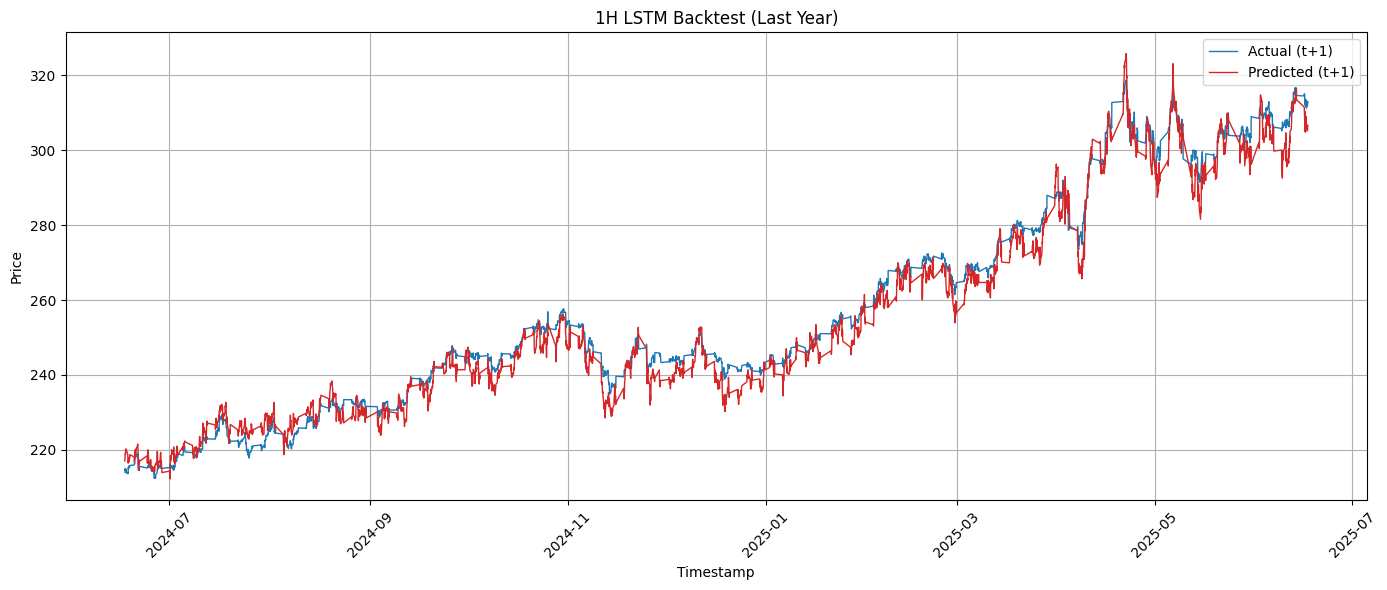

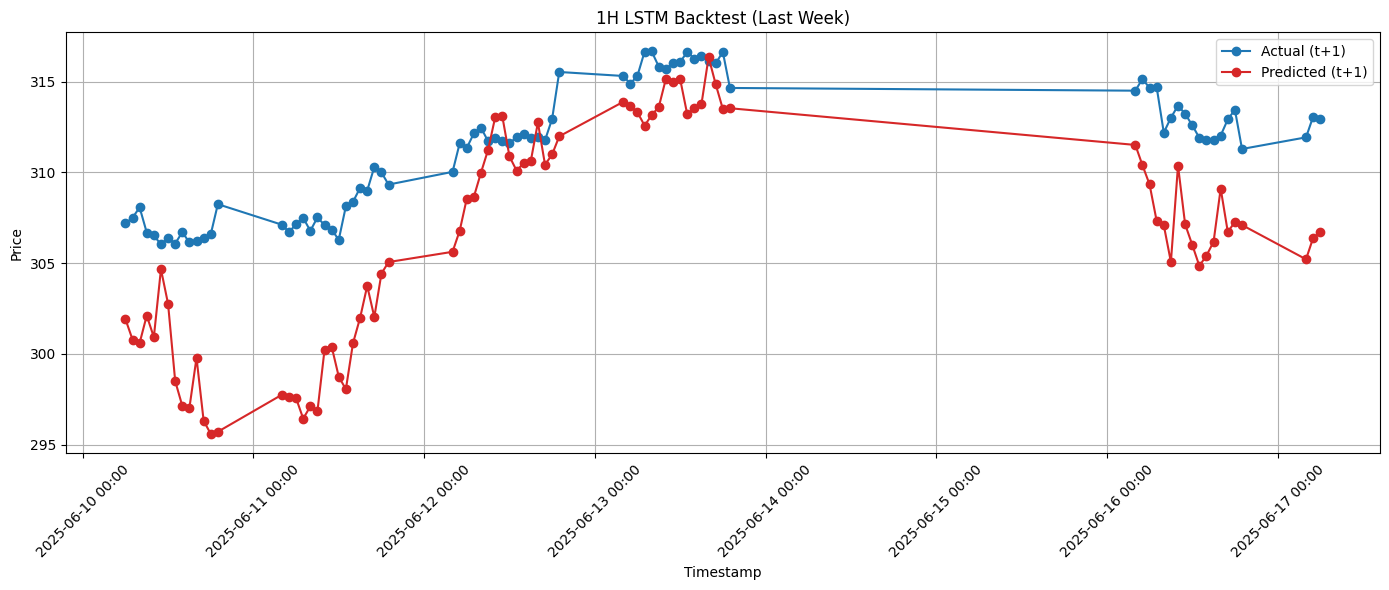

  -> Total Trades Taken: 679
Plotting equity curve for the last 5 years and computing performance metrics…
  -> Final capital (5Y): $134.58
  -> Total % Gain (5Y):   34.58%
  -> Approx. Sharpe (5Y): 0.23
  -> Max Drawdown (5Y):   -10.47%
  -> Win Rate (5Y):       53.46%


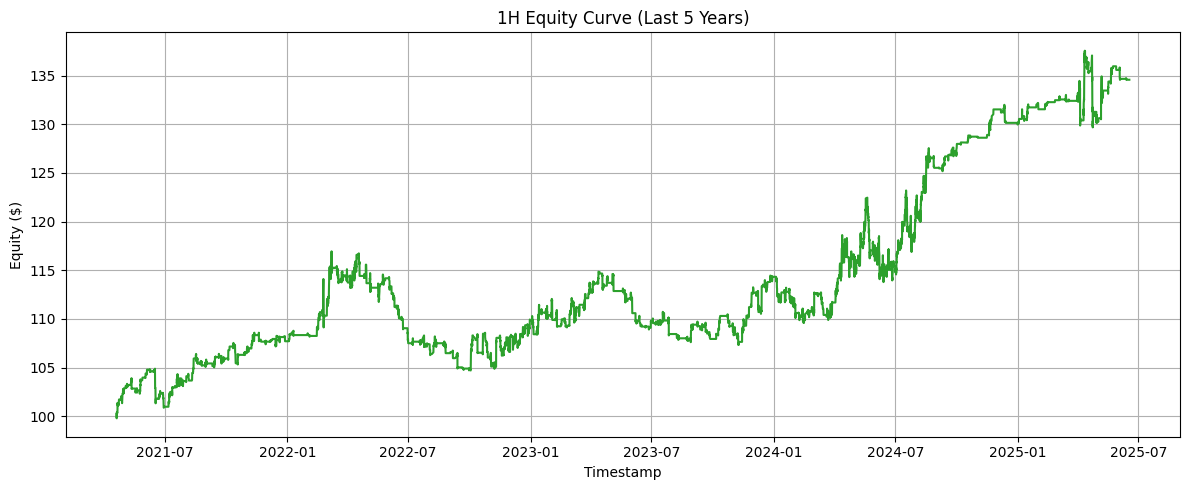

Retraining on full data for latest next-bar prediction…
  • Saved NEXT-BAR forecast -> lstm_outputs\predictions_1h.csv


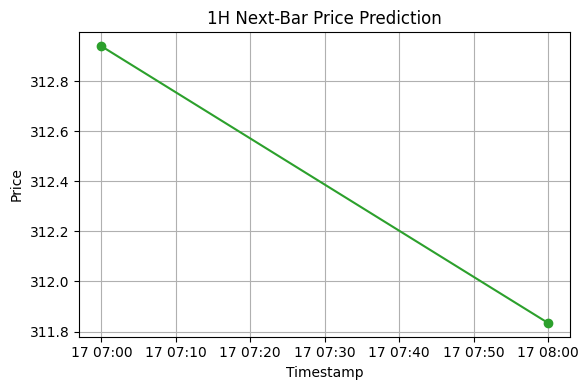


=== TIMEFRAME: 4H ===
Loading data from data_4h.csv...
Loaded 5425 rows, features: 75, close_col: close_4h
  • Rows: 5425, span 2020-06-18 04:00:00 -> 2025-06-16 16:00:00
Starting walk-forward backtest…
  • Fold 1/5
  • Fold 2/5
  • Fold 3/5
  • Fold 4/5
  • Fold 5/5
  -> AGGREGATED TEST MAE (return %): 3.264%
  -> AGGREGATED TEST RMSE (return %): 4.325%
  -> AGGREGATED DirAcc (binary):   50.20%


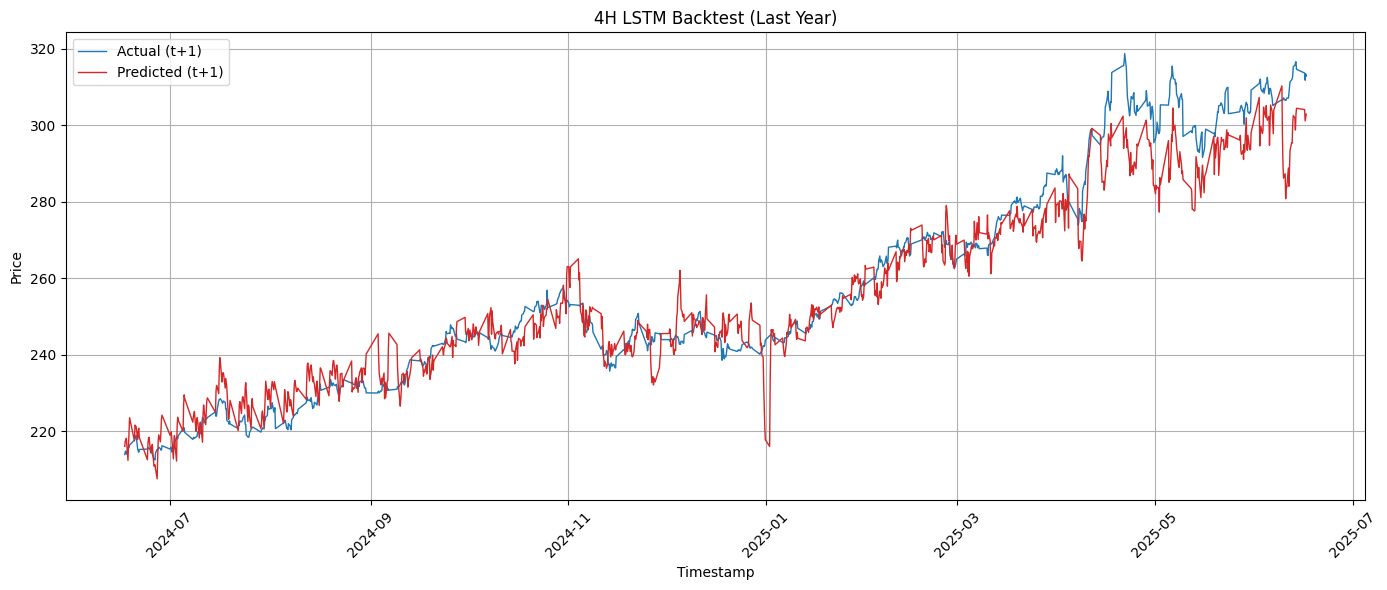

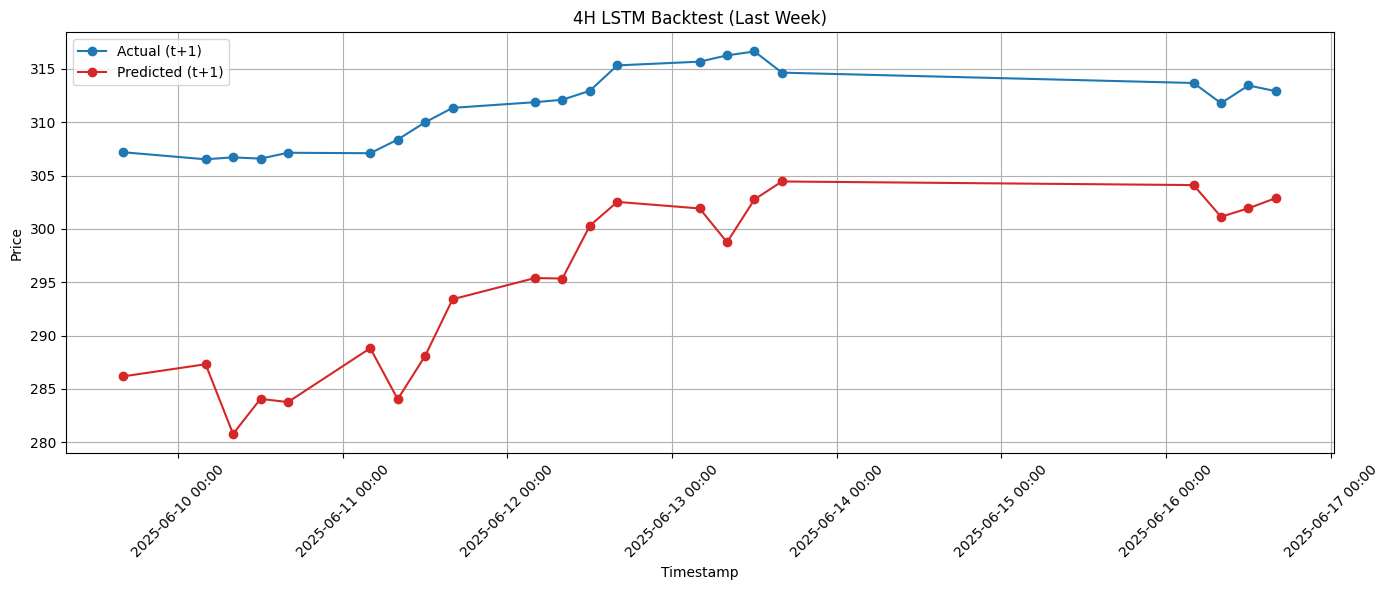

  -> Total Trades Taken: 288
Plotting equity curve for the last 5 years and computing performance metrics…
  -> Final capital (5Y): $148.37
  -> Total % Gain (5Y):   48.37%
  -> Approx. Sharpe (5Y): 0.47
  -> Max Drawdown (5Y):   -12.51%
  -> Win Rate (5Y):       51.39%


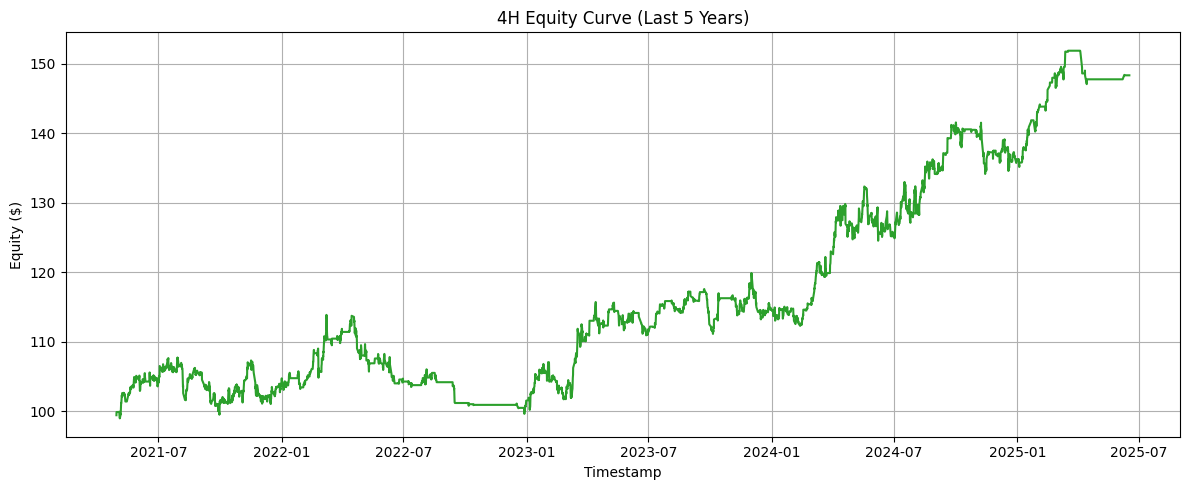

Retraining on full data for latest next-bar prediction…
  • Saved NEXT-BAR forecast -> lstm_outputs\predictions_4h.csv


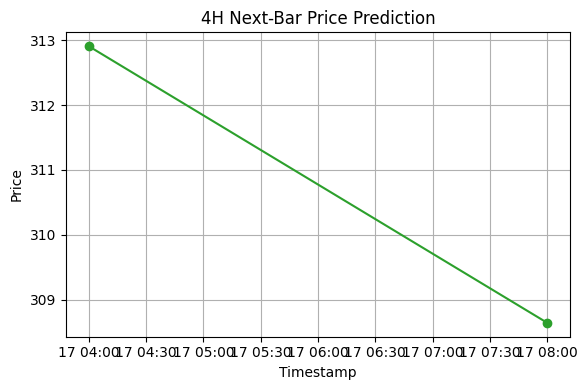


=== TIMEFRAME: 1D ===
Loading data from data_1d.csv...
Loaded 1254 rows, features: 75, close_col: close_1d
  • Rows: 1254, span 2020-06-18 00:00:00 -> 2025-06-13 00:00:00
Starting walk-forward backtest…
  • Fold 1/5
  • Fold 2/5
  • Fold 3/5
  • Fold 4/5
  • Fold 5/5
  -> AGGREGATED TEST MAE (return %): 4.861%
  -> AGGREGATED TEST RMSE (return %): 6.486%
  -> AGGREGATED DirAcc (binary):   51.06%


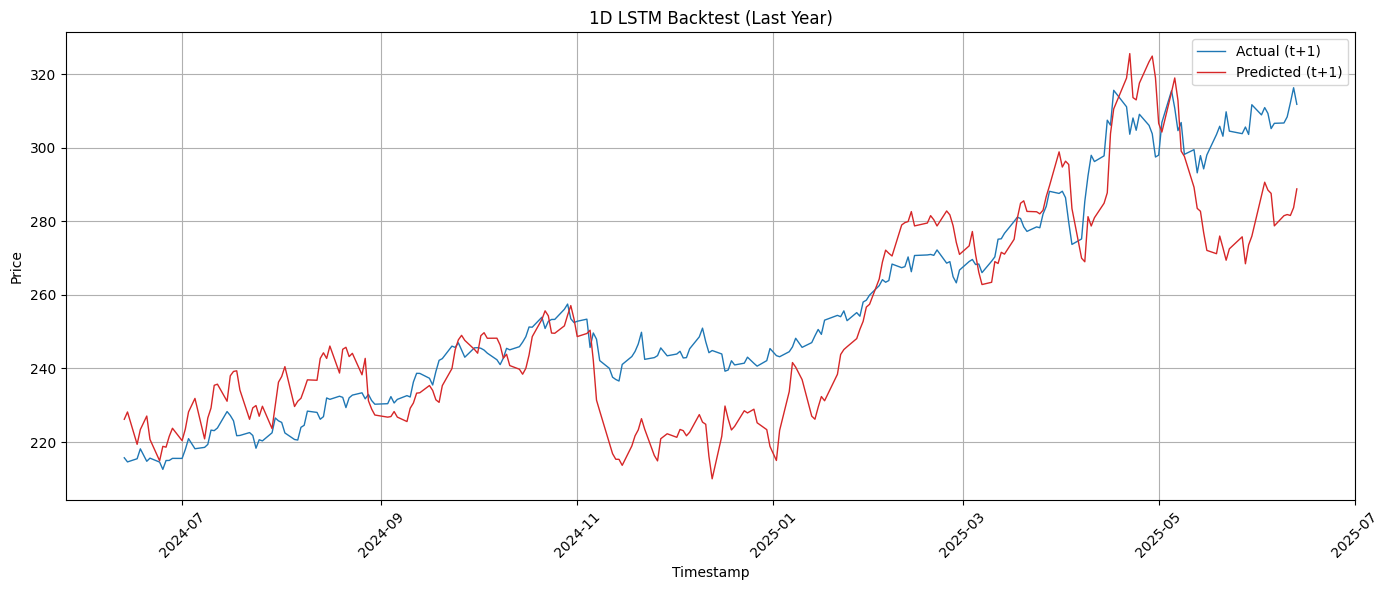

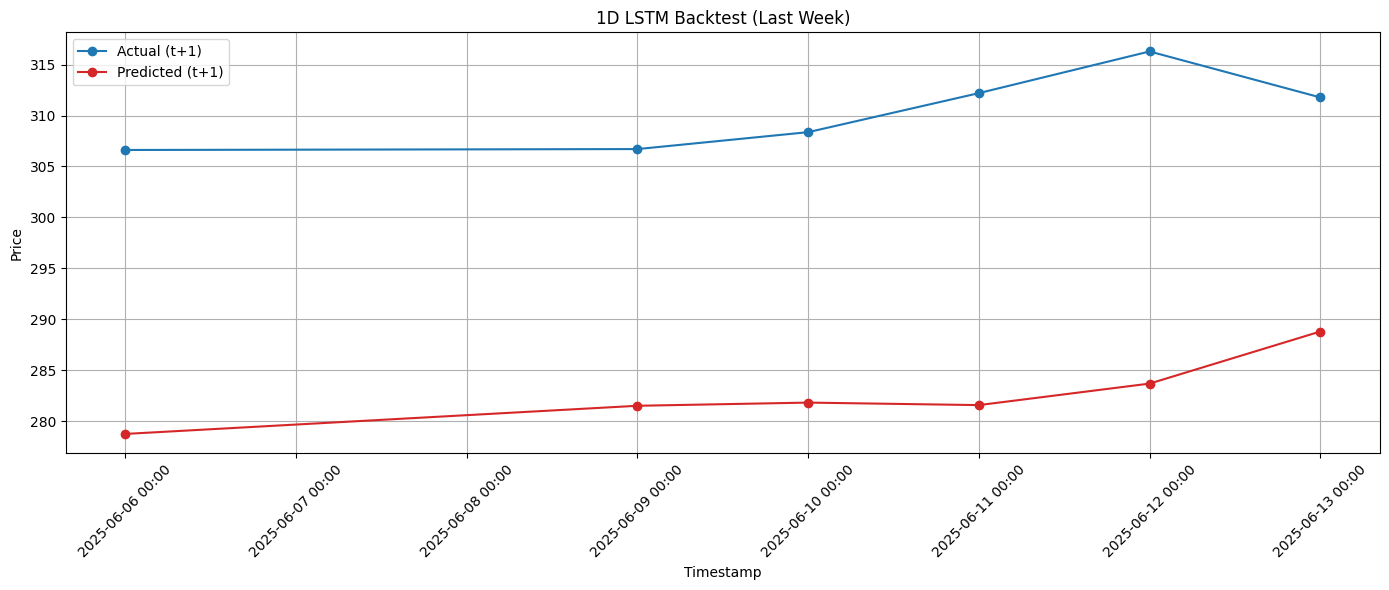

  -> Total Trades Taken: 58
Plotting equity curve for the last 5 years and computing performance metrics…
  -> Final capital (5Y): $142.27
  -> Total % Gain (5Y):   42.27%
  -> Approx. Sharpe (5Y): 0.81
  -> Max Drawdown (5Y):   -13.28%
  -> Win Rate (5Y):       55.17%


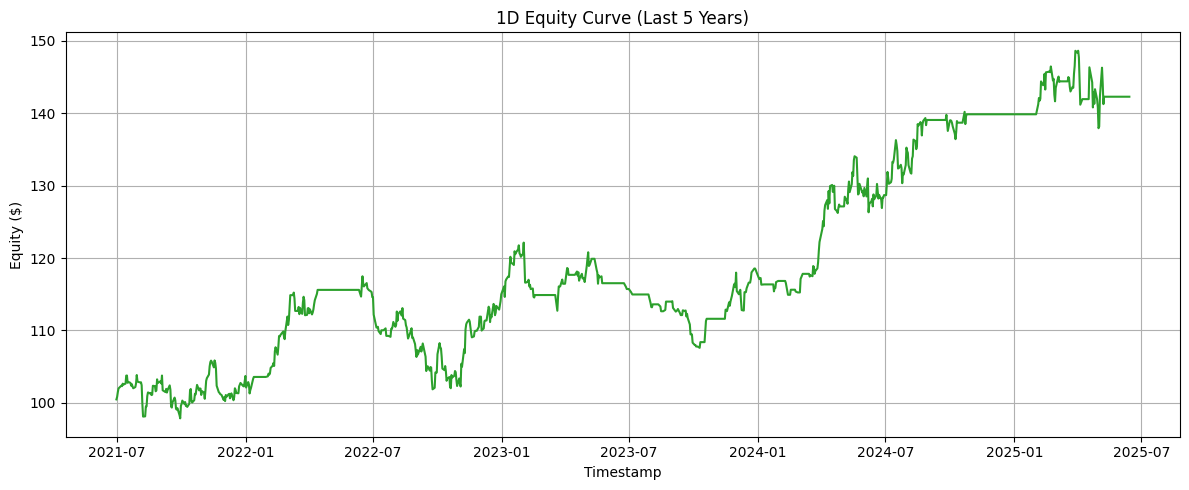

Retraining on full data for latest next-bar prediction…
  • Saved NEXT-BAR forecast -> lstm_outputs\predictions_1d.csv


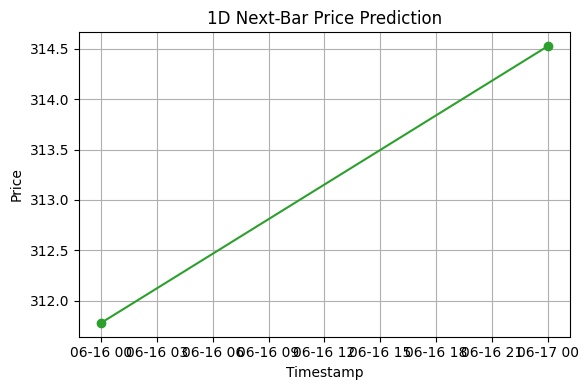


=== TIMEFRAME: 1W ===
Loading data from data_1w.csv...
Loaded 261 rows, features: 75, close_col: close_1w
  • Rows: 261, span 2020-06-14 00:00:00 -> 2025-06-08 00:00:00
Starting walk-forward backtest…
  • Fold 1/5
  • Fold 2/5
  • Fold 3/5
  • Fold 4/5
  • Fold 5/5
  -> AGGREGATED TEST MAE (return %): 9.792%
  -> AGGREGATED TEST RMSE (return %): 13.876%
  -> AGGREGATED DirAcc (binary):   56.36%


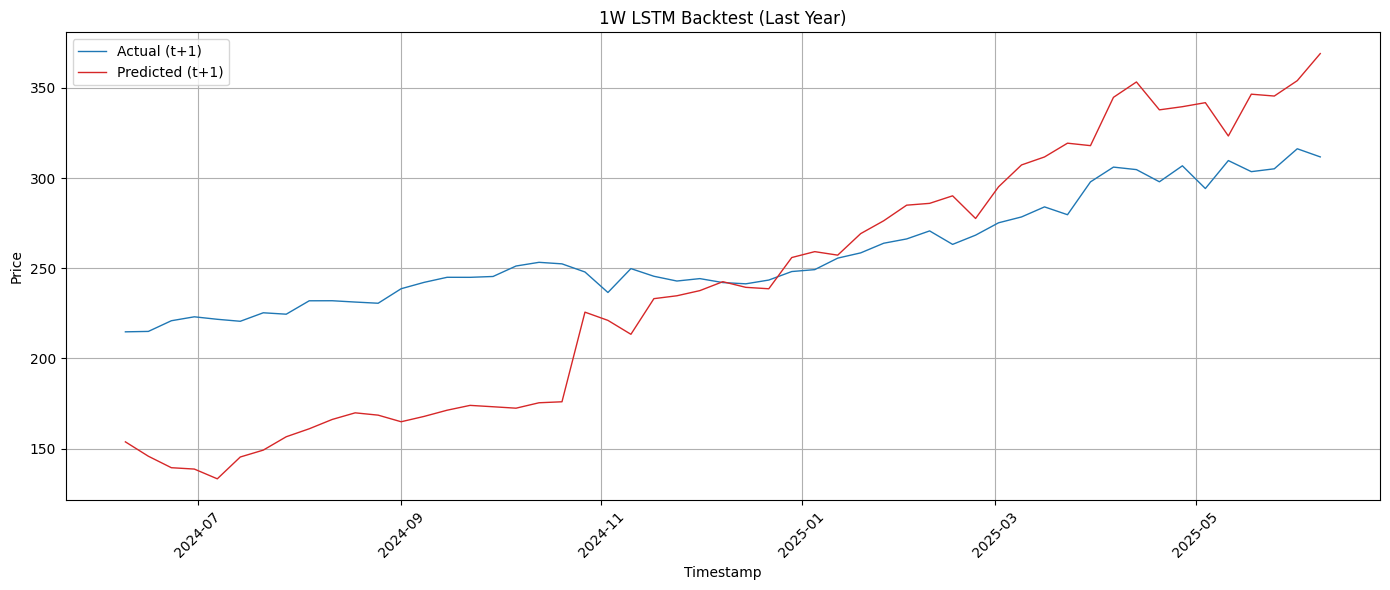

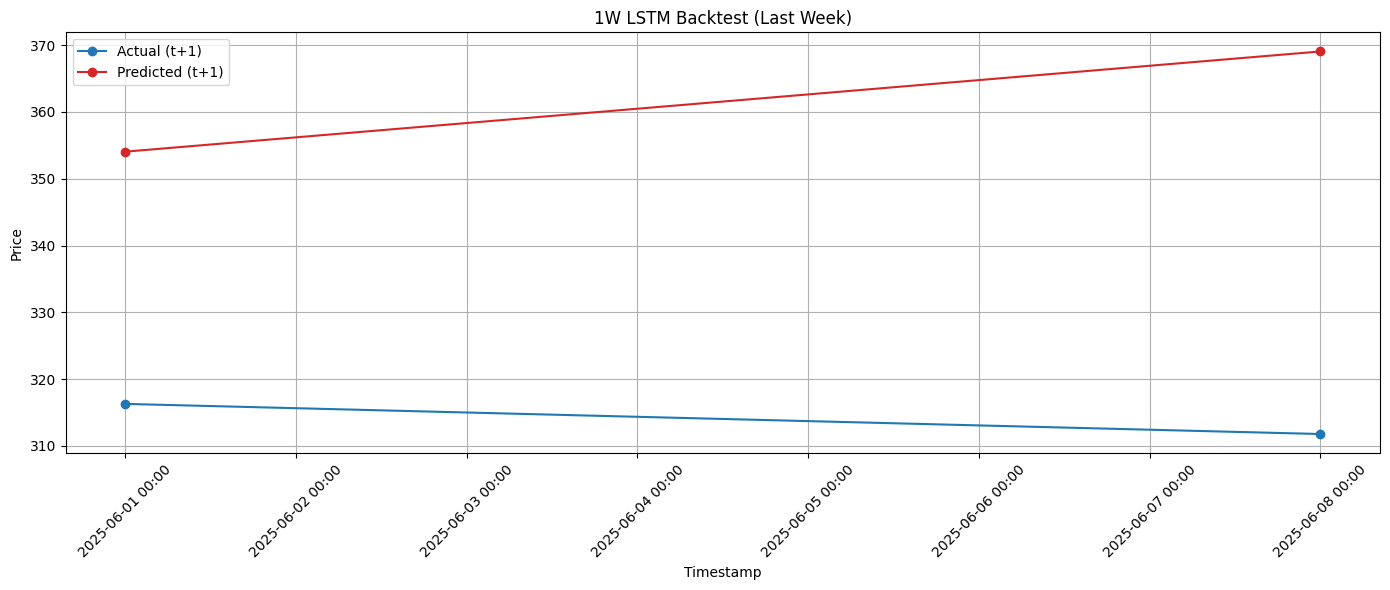

  -> Total Trades Taken: 6
Plotting equity curve for the last 5 years and computing performance metrics…
  -> Final capital (5Y): $163.21
  -> Total % Gain (5Y):   63.21%
  -> Approx. Sharpe (5Y): 3.87
  -> Max Drawdown (5Y):   -4.11%
  -> Win Rate (5Y):       66.67%


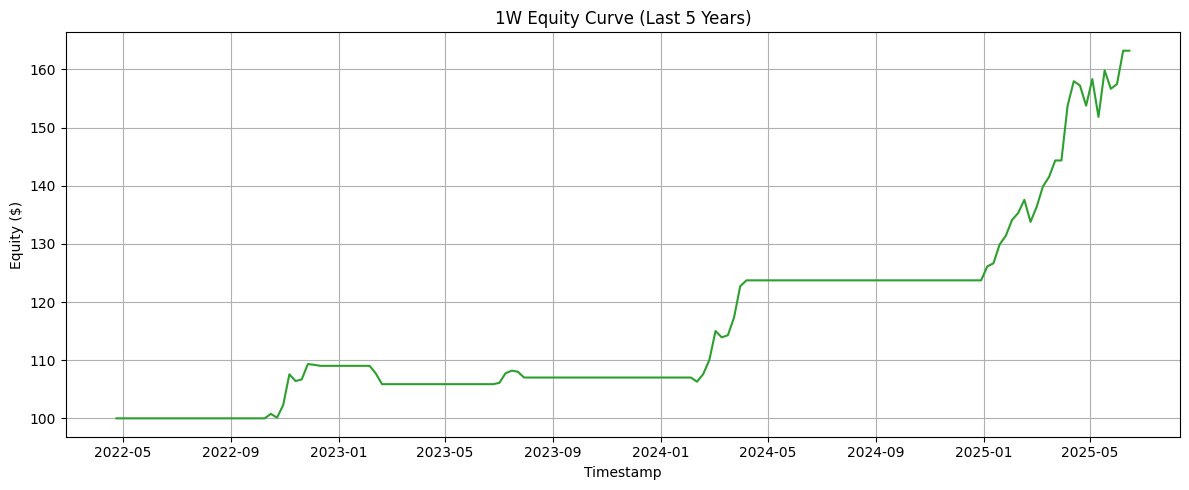

Retraining on full data for latest next-bar prediction…
  • Saved NEXT-BAR forecast -> lstm_outputs\predictions_1w.csv


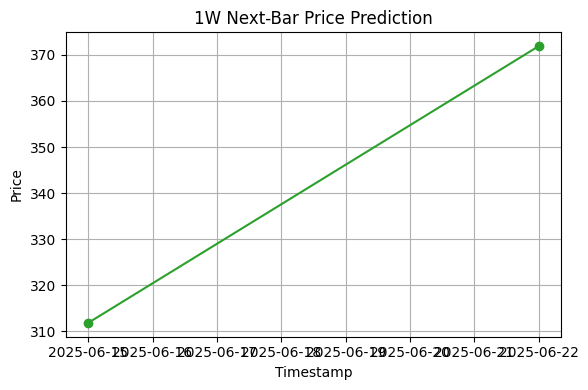


All timeframes completed.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import os
from datetime import timedelta
import warnings

# === CONFIGURATION ===
active_timeframes = ['1h', '4h', '1d', '1w']
data_files = {
    '1h': 'data_1h.csv',
    '4h': 'data_4h.csv',
    '1d': 'data_1d.csv',
    '1w': 'data_1w.csv'
}
output_dir = 'lstm_outputs'
os.makedirs(output_dir, exist_ok=True)

SEQ_LENGTH = 60
N_SPLITS = 5  # number of walk-forward folds

freq_steps = {
    '1h': timedelta(hours=1),
    '4h': timedelta(hours=4),
    '1d': timedelta(days=1),
    '1w': timedelta(weeks=1),
}

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')


def load_data(file_path):
    print(f"Loading data from {file_path}...")
    df = pd.read_csv(file_path, parse_dates=['timestamp'], index_col='timestamp')
    df.index = pd.to_datetime(df.index, errors='coerce')
    df = df[~df.index.isna()]
    df.sort_index(inplace=True)

    close_col = next((c for c in df.columns if c.lower().startswith('close_')), None)
    if close_col is None:
        raise ValueError(f"No column starting with 'close_' found in {file_path}")

    # indicators
    df['return_1'] = df[close_col].pct_change()
    df['SMA_10'] = df[close_col].rolling(10, min_periods=10).mean()
    df['SMA_20'] = df[close_col].rolling(20, min_periods=20).mean()
    delta = df[close_col].diff()
    up = delta.clip(lower=0)
    down = (-delta).clip(lower=0)
    roll_up = up.rolling(14, min_periods=14).mean()
    roll_down = down.rolling(14, min_periods=14).mean()
    RS = roll_up / (roll_down + 1e-9)
    df['RSI_14'] = 100.0 - (100.0 / (1.0 + RS))

    # targets
    df['target_reg'] = df[close_col].shift(-1) / df[close_col] - 1.0
    df['target_bin'] = (df['target_reg'] > 0).astype(int)
    df.dropna(subset=['target_reg', 'target_bin'], inplace=True)

    numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric if c not in ('target_reg','target_bin')]
    feat = df[feature_cols].ffill().bfill().dropna(axis=1, how='all')

    y_reg = df['target_reg'].loc[feat.index].values
    y_bin = df['target_bin'].loc[feat.index].values

    print(f"Loaded {len(feat)} rows, features: {len(feature_cols)}, close_col: {close_col}")
    return feat, y_reg, y_bin, close_col


def create_sequences(X, y_reg, y_bin, seq_len):
    Xs, yrs, ybs, idxs = [], [], [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        yrs.append(y_reg[i])
        ybs.append(y_bin[i])
        idxs.append(i)
    return np.array(Xs), np.array(yrs), np.array(ybs), np.array(idxs)


def build_model(n_features):
    inp = Input(shape=(SEQ_LENGTH, n_features))
    x = LSTM(50)(inp)
    x = Dropout(0.2)(x)
    r = Dense(1, name='reg_output')(x)
    b = Dense(1, activation='sigmoid', name='bin_output')(x)
    model = Model(inputs=inp, outputs=[r, b])
    model.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss={'reg_output': 'mse', 'bin_output': 'binary_crossentropy'},
        loss_weights={'reg_output': 0.5, 'bin_output': 0.5}
    )
    # --- FIX: pre-build the internal tf.function for predict to avoid retracing warnings ---
    model.make_predict_function()
    return model


for tf in active_timeframes:
    print(f"\n=== TIMEFRAME: {tf.upper()} ===")
    fp = data_files.get(tf, "")
    if not os.path.isfile(fp):
        print(f"  • File not found: {fp}. Skipping.")
        continue

    # --- load & prepare ---
    feat_df, y_reg_all, y_bin_all, close_col = load_data(fp)
    if len(feat_df) <= SEQ_LENGTH:
        print("  • Not enough data after cleaning. Skipping.")
        continue

    print(f"  • Rows: {len(feat_df)}, span {feat_df.index.min()} -> {feat_df.index.max()}")

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(feat_df.values.astype('float32'))

    X_all, y_reg_all, y_bin_all, idxs_all = create_sequences(
        X_scaled, y_reg_all, y_bin_all, SEQ_LENGTH
    )
    ts_all = feat_df.index.values[idxs_all]
    close_prices = feat_df[close_col].values

    # --- walk-forward backtest ---
    print("Starting walk-forward backtest…")
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    wf_equity   = []
    wf_trades   = 0
    wf_wins     = 0
    wf_capital  = 100.0
    wf_position = 0.0
    # — profit / stop-loss settings —
    profit_target = 1.00    # close when +15% P&L
    stop_loss     = -1.00   # close when −5% P&L
    
    # for aggregated metrics & plots
    all_preds_reg, all_preds_bin = [], []
    all_y_reg, all_y_bin = [], []
    all_idxs, all_ts = [], []

    for fold, (train_ix, test_ix) in enumerate(tscv.split(X_all), 1):
        print(f"  • Fold {fold}/{N_SPLITS}")
        X_tr, X_te = X_all[train_ix], X_all[test_ix]
        yr_tr, yb_tr = y_reg_all[train_ix], y_bin_all[train_ix]
        idx_te = idxs_all[test_ix]
        ts_te = ts_all[test_ix]

        # train
        model = build_model(X_all.shape[2])
        model.fit(
            X_tr,
            {'reg_output': yr_tr, 'bin_output': yb_tr},
            epochs=3, batch_size=32, verbose=0
        )

        # predict (fixed batch_size avoids retracing)
        ypr, ypb = model.predict(X_te, batch_size=32, verbose=0)
        ypr = ypr.flatten()
        ypb = (ypb.flatten() > 0.5).astype(int)

        # collect
        all_preds_reg.append(ypr)
        all_preds_bin.append(ypb)
        all_y_reg.append(y_reg_all[test_ix])
        all_y_bin.append(y_bin_all[test_ix])
        all_idxs.append(idx_te)
        all_ts.append(ts_te)

        # simulate trades
        for i, idx in enumerate(idx_te):
            price  = close_prices[idx]
            next_p = close_prices[idx+1] if idx+1 < len(close_prices) else price
            pred_p = price * (1 + ypr[i])

            # — ENTRY —
            if wf_position == 0 and pred_p > price:
                wf_position = wf_capital / price
                entry_price = price
                wf_capital  = 0.0
                wf_trades  += 1

            # — EXIT —
            elif wf_position > 0:
                # current P&L since entry
                pnl = (price - entry_price) / entry_price

                # 1) profit-target or stop-loss hit?
                if pnl >= profit_target or pnl <= stop_loss:
                    if pnl > 0:
                        wf_wins += 1
                    # exit at current price
                    wf_capital  = wf_position * price
                    wf_position = 0.0

                # 2) otherwise, your original pred-based exit
                elif pred_p < price:
                    if next_p > entry_price:
                        wf_wins += 1
                    wf_capital  = wf_position * next_p
                    wf_position = 0.0

            # record equity
            equity = wf_capital if wf_position == 0 else wf_position * next_p
            wf_equity.append({
                'timestamp': pd.Timestamp(ts_te[i]) + freq_steps[tf],
                'equity': equity
            })


    # flatten arrays
    all_preds_reg = np.concatenate(all_preds_reg)
    all_preds_bin = np.concatenate(all_preds_bin)
    all_y_reg = np.concatenate(all_y_reg)
    all_y_bin = np.concatenate(all_y_bin)
    all_idxs = np.concatenate(all_idxs)
    all_ts = np.concatenate(all_ts)

    # metrics
    mae = mean_absolute_error(all_y_reg, all_preds_reg) * 100
    rmse = np.sqrt(mean_squared_error(all_y_reg, all_preds_reg)) * 100
    dir_acc = accuracy_score(all_y_bin, all_preds_bin) * 100

    print(f"  -> AGGREGATED TEST MAE (return %): {mae:.3f}%")
    print(f"  -> AGGREGATED TEST RMSE (return %): {rmse:.3f}%")
    print(f"  -> AGGREGATED DirAcc (binary):   {dir_acc:.2f}%")

    # 1-YEAR & 1-WEEK price vs predicted
    actual_prices = close_prices[all_idxs] * (1 + all_y_reg)
    predicted_prices = close_prices[all_idxs] * (1 + all_preds_reg)

    cutoff_1y = all_ts.max() - pd.Timedelta(days=365)
    m1 = all_ts >= cutoff_1y
    plt.figure(figsize=(14,6))
    plt.plot(all_ts[m1], actual_prices[m1], label='Actual (t+1)', color='C0', linewidth=1)
    plt.plot(all_ts[m1], predicted_prices[m1], label='Predicted (t+1)', color='C3', linewidth=1)
    plt.title(f"{tf.upper()} LSTM Backtest (Last Year)")
    plt.xlabel("Timestamp"); plt.ylabel("Price")
    plt.legend(); plt.grid(True)
    plt.gca().xaxis.set_major_formatter(DateFormatter("%Y-%m"))
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()

    cutoff_1w = all_ts.max() - pd.Timedelta(days=7)
    m2 = all_ts >= cutoff_1w
    if m2.any():
        plt.figure(figsize=(14,6))
        plt.plot(all_ts[m2], actual_prices[m2], marker='o', linestyle='-', label='Actual (t+1)', color='C0')
        plt.plot(all_ts[m2], predicted_prices[m2], marker='o', linestyle='-', label='Predicted (t+1)', color='C3')
        plt.title(f"{tf.upper()} LSTM Backtest (Last Week)")
        plt.xlabel("Timestamp"); plt.ylabel("Price")
        plt.legend(); plt.grid(True)
        plt.gca().xaxis.set_major_formatter(DateFormatter("%Y-%m-%d %H:%M"))
        plt.xticks(rotation=45); plt.tight_layout(); plt.show()

    # equity curve & perf metrics
    eq_df = pd.DataFrame(wf_equity).set_index('timestamp').sort_index()
    final_cap = eq_df['equity'].iloc[-1]
    pct_gain  = (final_cap - 100.0) / 100.0 * 100
    rets      = eq_df['equity'].pct_change().dropna()
    sharpe    = rets.mean() / (rets.std()+1e-9) * np.sqrt(252) if not rets.empty else 0
    drawdown  = (eq_df['equity']/eq_df['equity'].cummax() - 1).min() * 100
    win_rate  = (wf_wins / wf_trades * 100) if wf_trades > 0 else 0.0
    print(f"  -> Total Trades Taken: {wf_trades}")

    print("Plotting equity curve for the last 5 years and computing performance metrics…")
    print(f"  -> Final capital (5Y): ${final_cap:.2f}")
    print(f"  -> Total % Gain (5Y):   {pct_gain:.2f}%")
    print(f"  -> Approx. Sharpe (5Y): {sharpe:.2f}")
    print(f"  -> Max Drawdown (5Y):   {drawdown:.2f}%")
    print(f"  -> Win Rate (5Y):       {win_rate:.2f}%")

    cutoff_5y = eq_df.index.max() - pd.DateOffset(years=5)
    eq5 = eq_df.loc[eq_df.index >= cutoff_5y] if not eq_df.empty else eq_df
    plt.figure(figsize=(12,5))
    plt.plot(eq5.index, eq5['equity'], label='Equity', color='C2')
    plt.title(f"{tf.upper()} Equity Curve (Last 5 Years)")
    plt.xlabel("Timestamp"); plt.ylabel("Equity ($)")
    plt.grid(True); plt.tight_layout(); plt.show()

    # === FINAL NEXT-BAR PREDICTION ===
    print("Retraining on full data for latest next-bar prediction…")
    model.fit(
        X_all,
        {'reg_output': y_reg_all, 'bin_output': y_bin_all},
        epochs=3, batch_size=32, verbose=0
    )

    raw_df = pd.read_csv(fp, parse_dates=['timestamp'], index_col='timestamp')
    raw_df.index = pd.to_datetime(raw_df.index)
    raw = raw_df.copy()
    raw['return_1'] = raw[close_col].pct_change()
    raw['SMA_10'] = raw[close_col].rolling(10, min_periods=10).mean()
    raw['SMA_20'] = raw[close_col].rolling(20, min_periods=20).mean()
    delta = raw[close_col].diff()
    up = delta.clip(lower=0)
    down = (-delta).clip(lower=0)
    ru = up.rolling(14, min_periods=14).mean()
    rd = down.rolling(14, min_periods=14).mean()
    RS = ru / (rd + 1e-9)
    raw['RSI_14'] = 100 - (100 / (1 + RS))

    rf = raw[feat_df.columns].ffill().bfill()
    full_scaled = scaler.transform(rf.values.astype('float32'))
    last_seq = np.expand_dims(full_scaled[-SEQ_LENGTH:], axis=0)
    pr, pd_bin = model(last_seq, training=False)
    pr = float(pr.numpy().flatten()[0])
    pd_bin = int((pd_bin.numpy().flatten()[0] > 0.5).astype(int))

    last_close = raw_df[close_col].iloc[-1]
    next_ts = raw_df.index[-1] + freq_steps[tf]
    pred_price = last_close * (1 + pr)

    outfile = os.path.join(output_dir, f"predictions_{tf}.csv")
    pd.DataFrame([{ 'timestamp': next_ts,
                    'predicted_price': pred_price,
                    'predicted_direction': pd_bin
    }]).to_csv(outfile, index=False)
    print(f"  • Saved NEXT-BAR forecast -> {outfile}")

    plt.figure(figsize=(6,4))
    plt.plot([raw_df.index[-1], next_ts], [last_close, pred_price], marker='o', color='C2')
    plt.title(f"{tf.upper()} Next-Bar Price Prediction")
    plt.xlabel("Timestamp"); plt.ylabel("Price")
    plt.grid(True); plt.tight_layout(); plt.show()

print("\nAll timeframes completed.")


History: 2004-11-18 to 2025-06-16
Predictions for GLD: {'1 Week': 0.27, '1 Month': 0.56, '1 Year': 0.88}


Equity Backtest tgt_1w: 100%|██████████████████████████████████████████████████████| 1259/1259 [05:20<00:00,  3.93it/s]


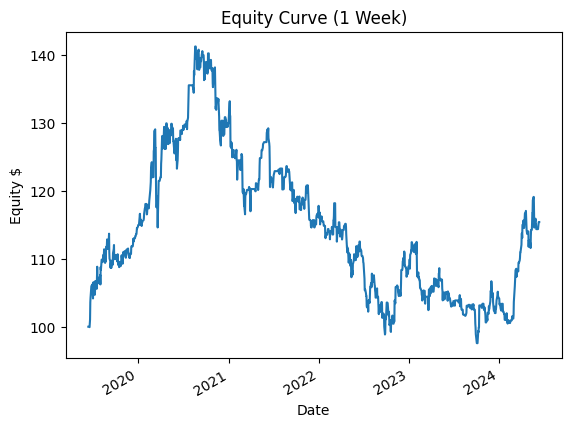

Equity Backtest tgt_1m: 100%|██████████████████████████████████████████████████████| 1259/1259 [05:13<00:00,  4.02it/s]


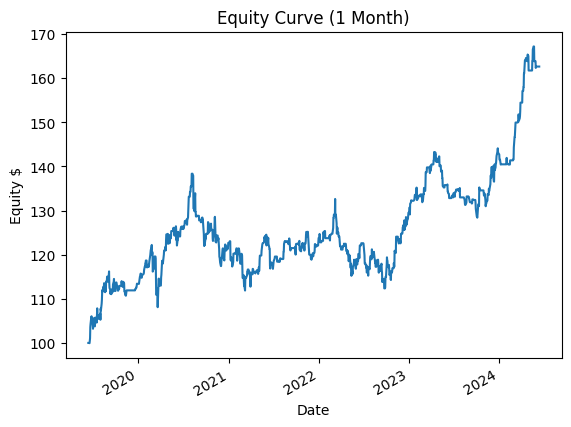

Equity Backtest tgt_1y: 100%|██████████████████████████████████████████████████████| 1259/1259 [04:46<00:00,  4.40it/s]


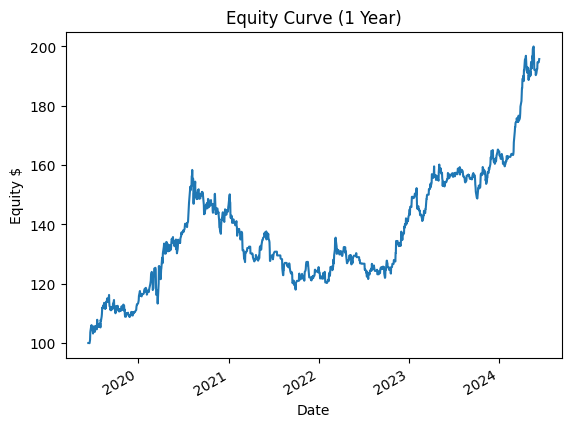

In [6]:
# Single-Stock Probability Prediction, Backtesting, and Equity Simulation (5-Year Window)
# Focus on one ticker, fetch full history, generate features,
# predict probabilities, backtest signals with take-profit/stop-loss and probability-based exits, simulate equity curves, and plot.

# Define parameters
ticker = 'GLD'  # Mastercard
THRESHOLD = 0.5           # probability cutoff for buy/sell signals
INITIAL_CAPITAL = 100.0   # starting equity for simulation
TAKE_PROFIT = 1.00       # 3% take-profit
STOP_LOSS = 1.00         # 1% stop-loss

# Imports
import time
import warnings
import pandas as pd
import numpy as np
import requests
from io import StringIO
from datetime import datetime
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
from tqdm import tqdm  # progress bar for loops

warnings.filterwarnings('ignore', message='X does not have valid feature names', category=UserWarning)

# HTTP headers to avoid 429 errors
HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/91.0.4472.124 Safari/537.36'
    )
}

# Fetch full available history via Yahoo chart API
def fetch_data(symbol, retries=3, backoff=1):
    start = 0
    end = int(datetime.now().timestamp())
    url = (
        f'https://query1.finance.yahoo.com/v8/finance/chart/{symbol}'
        f'?period1={start}&period2={end}&interval=1d'
    )
    for i in range(retries):
        resp = requests.get(url, headers=HEADERS)
        if resp.status_code == 200:
            result = resp.json().get('chart', {}).get('result')
            if not result:
                raise ValueError(f"No data for {symbol}")
            vals = result[0]
            df = pd.DataFrame({
                'Date': pd.to_datetime(vals['timestamp'], unit='s'),
                'Open': vals['indicators']['quote'][0]['open'],
                'High': vals['indicators']['quote'][0]['high'],
                'Low': vals['indicators']['quote'][0]['low'],
                'Close': vals['indicators']['quote'][0]['close'],
                'Volume': vals['indicators']['quote'][0]['volume'],
            }).set_index('Date')
            return df.dropna()
        elif resp.status_code == 429:
            time.sleep(backoff * (2 ** i))
        else:
            resp.raise_for_status()
    raise ConnectionError(f"Failed to fetch {symbol} after retries")

# Feature engineering
def generate_features(df):
    df2 = df.copy()
    df2['ret_1d'] = df2['Close'].pct_change()
    df2['ret_5d'] = df2['Close'].pct_change(5)
    df2['rsi'] = RSIIndicator(df2['Close'], window=14).rsi()
    bb = BollingerBands(df2['Close'], window=20, window_dev=2)
    df2['pct_bb'] = (
        df2['Close'] - bb.bollinger_lband()
    ) / (bb.bollinger_hband() - bb.bollinger_lband())
    df2['fut_5d'] = df2['Close'].shift(-5)
    df2['fut_21d'] = df2['Close'].shift(-21)
    df2['fut_252d'] = df2['Close'].shift(-252)
    df2.dropna(inplace=True)
    df2['tgt_1w'] = (df2['fut_5d'] > df2['Close']).astype(int)
    df2['tgt_1m'] = (df2['fut_21d'] > df2['Close']).astype(int)
    df2['tgt_1y'] = (df2['fut_252d'] > df2['Close']).astype(int)
    return df2

# Train & predict for the most recent date
def train_predict(df_feat, features, target):
    X = df_feat[features]
    y = df_feat[target]
    max_splits = len(X) - 1
    n_splits = min(5, max_splits)
    if n_splits < 2:
        return float('nan')
    tscv = TimeSeriesSplit(n_splits=n_splits)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    for train_idx, _ in tscv.split(X):
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]
    model.fit(X_train, y_train)
    probs = model.predict_proba(X.iloc[[-1]])[0]
    classes = model.classes_
    prob_up = probs[list(classes).index(1)] if 1 in classes else 0.0
    return float(prob_up)

# Simulate equity curve based on backtest signals with TP/SL and model exits
from pandas import DateOffset

def equity_backtest(df_feat, features, target,
                    threshold=THRESHOLD,
                    init_cash=INITIAL_CAPITAL,
                    take_profit=TAKE_PROFIT,
                    stop_loss=STOP_LOSS):
    # Copy & slice to last 5 years
    df2 = df_feat.copy()
    cutoff = df2.index.max() - DateOffset(years=5)
    df2 = df2[df2.index >= cutoff]

    # Prepare columns & state
    df2['signal'] = 0
    df2['equity'] = init_cash
    cash = init_cash
    position = 0.0
    entry_price = None

    for i in tqdm(range(len(df2) - 1), desc=f"Equity Backtest {target}"):
        price = df2['Close'].iat[i]
        prob = train_predict(df2.iloc[:i+1], features, target)
        buy_signal = (prob >= threshold)

        # Entry: go long if model bullish and flat
        if buy_signal and position == 0:
            position = cash / price
            cash = 0.0
            entry_price = price

        # Exit: TP/SL or model turns bearish
        elif position > 0:
            if (price >= entry_price * (1 + take_profit)
                or price <= entry_price * (1 - stop_loss)
                or prob < threshold):
                cash = position * price
                position = 0.0
                entry_price = None

        # Record signal & equity
        df2['signal'].iat[i] = 1 if position > 0 else 0
        df2['equity'].iat[i] = cash + position * price

    # Final equity at last close
    final_price = df2['Close'].iat[-1]
    df2['equity'].iat[-1] = cash + position * final_price
    return df2['equity']

# Main execution
if __name__ == '__main__':
    df = fetch_data(ticker)
    print(f"History: {df.index.min().date()} to {df.index.max().date()}")
    df_feat = generate_features(df)
    features = ['ret_1d', 'ret_5d', 'rsi', 'pct_bb']
    horizons = {'tgt_1w': '1 Week', 'tgt_1m': '1 Month', 'tgt_1y': '1 Year'}

    preds = {label: train_predict(df_feat, features, tgt) for tgt, label in horizons.items()}
    print(f"Predictions for {ticker}: {preds}")

    for tgt, label in horizons.items():
        eq = equity_backtest(df_feat, features, tgt)
        plt.figure()
        eq.plot()
        plt.title(f"Equity Curve ({label})")
        plt.ylabel('Equity $')
        plt.xlabel('Date')
        plt.show()
